## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
abs_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv")
abs_val   = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv")
abs_test  = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv")

rel_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv")
rel_val   = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv")
rel_test  = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv")

/tmp/ipykernel_20342/191890810.py:1: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv")
/tmp/ipykernel_20342/191890810.py:5: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv")


## 1. Exploratory Data Analysis (EDA)

### 1.1 Basic quality checks

In [17]:
feature_cols = [c for c in abs_train.columns if c.startswith("G")]

abs_feats = abs_train[feature_cols].apply(pd.to_numeric, errors="coerce")
rel_feats = rel_train[feature_cols].apply(pd.to_numeric, errors="coerce")

print("abs NA (features):", abs_feats.isna().sum().sum())
print("abs negative (features):", (abs_feats < 0).sum().sum())
print("abs shape:", abs_train.shape)

print("rel NA (features):", rel_feats.isna().sum().sum())
print("rel negative (features):", (rel_feats < 0).sum().sum())
print("rel shape:", rel_train.shape)

abs NA (features): 0
abs negative (features): 0
abs shape: (1910, 1292)
rel NA (features): 0
rel negative (features): 0
rel shape: (1910, 1292)


### 1.2 Distribution Diagnostics

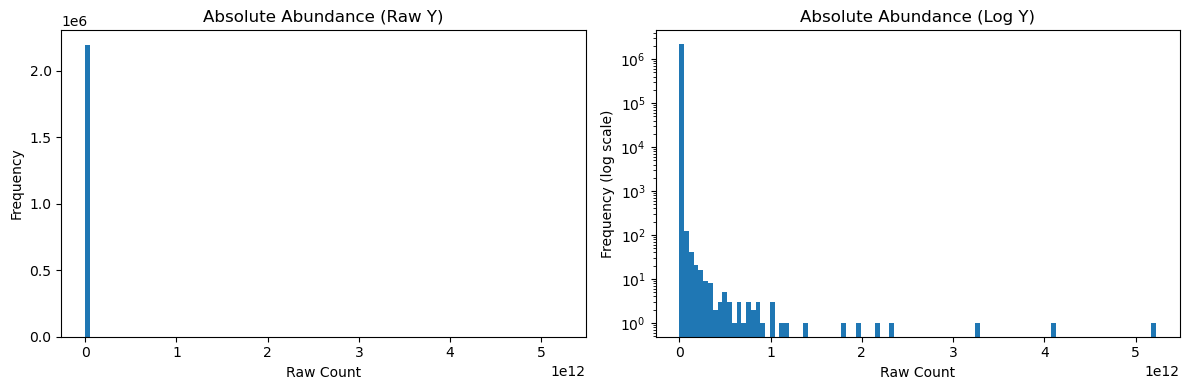

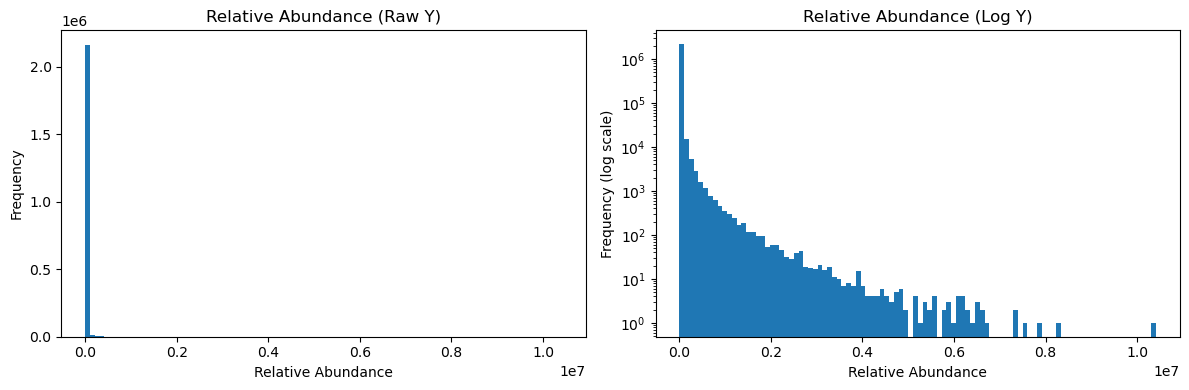

In [6]:
# Flatten feature values
abs_vals = abs_train[[c for c in abs_train.columns if c.startswith("G")]].values.flatten()
rel_vals = rel_train[[c for c in rel_train.columns if c.startswith("G")]].values.flatten()

# ABSOLUTE ABUNDANCE
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Raw Y-scale
axes[0].hist(abs_vals, bins=100)
axes[0].set_title("Absolute Abundance (Raw Y)")
axes[0].set_xlabel("Raw Count")
axes[0].set_ylabel("Frequency")

# Log Y-scale
axes[1].hist(abs_vals, bins=100)
axes[1].set_yscale("log")
axes[1].set_title("Absolute Abundance (Log Y)")
axes[1].set_xlabel("Raw Count")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()


# RELATIVE ABUNDANCE
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Raw Y-scale
axes[0].hist(rel_vals, bins=100)
axes[0].set_title("Relative Abundance (Raw Y)")
axes[0].set_xlabel("Relative Abundance")
axes[0].set_ylabel("Frequency")

# Log Y-scale
axes[1].hist(rel_vals, bins=100)
axes[1].set_yscale("log")
axes[1].set_title("Relative Abundance (Log Y)")
axes[1].set_xlabel("Relative Abundance")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

In [7]:
print("ABS max:", X_abs_train.max().max())
print("REL max:", X_rel_train.max().max())

print("REL row sum stats:")
print(X_rel_train.sum(axis=1).describe())

ABS max: 5225222801820.961
REL max: 10415540.0
REL row sum stats:
count    1.910000e+03
mean     8.951591e+06
std      3.526548e+06
min      4.218000e+03
25%      6.612083e+06
50%      8.520516e+06
75%      1.085802e+07
max      3.149474e+07
dtype: float64


### 1.3 Log transform counts

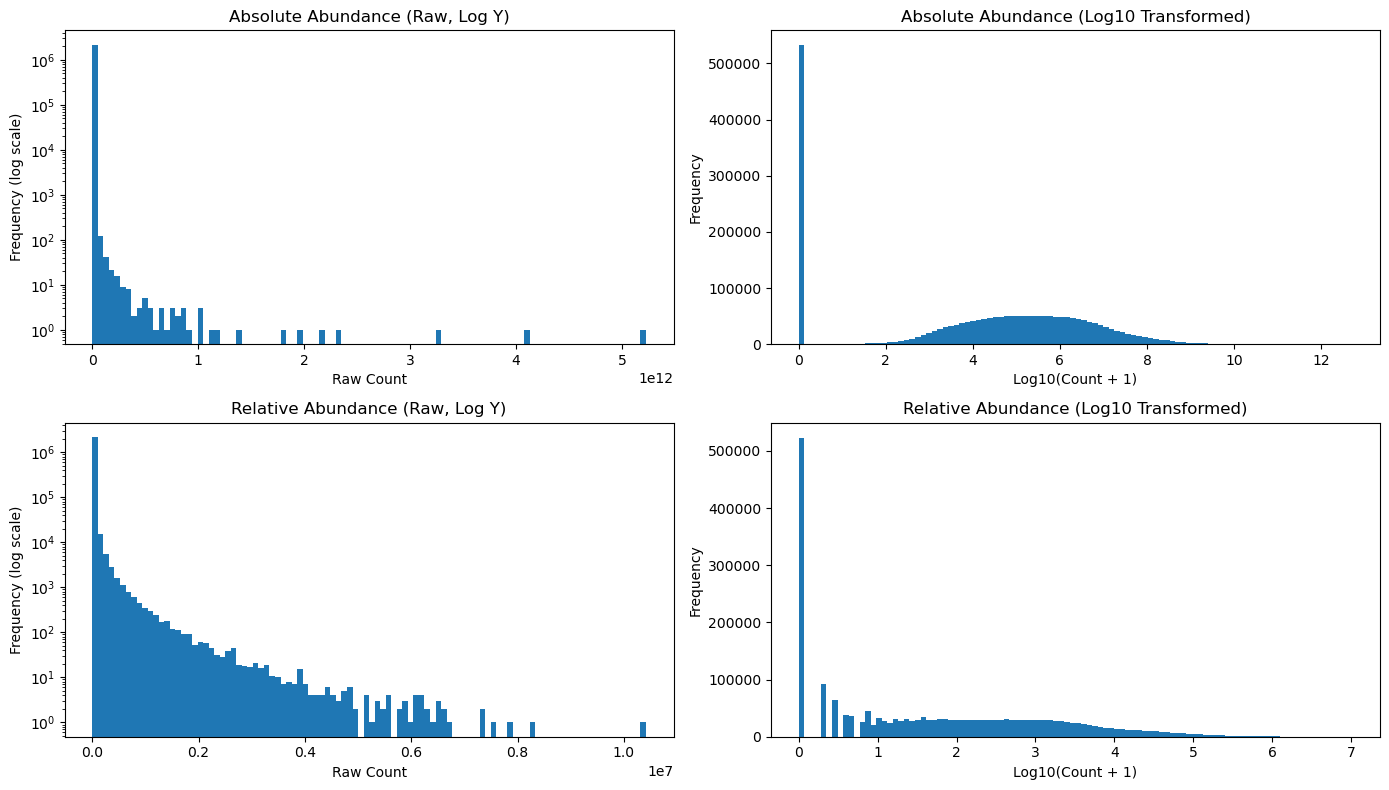

In [20]:
# Flatten values
abs_vals = abs_train[[c for c in abs_train.columns if c.startswith("G")]].values.flatten()
rel_vals = rel_train[[c for c in rel_train.columns if c.startswith("G")]].values.flatten()

# Log transform
abs_log = np.log10(abs_vals + 1)
rel_log = np.log10(rel_vals + 1)

# Plot 2x2 Diagnostic Panel
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ---- Absolute Raw ----
axes[0, 0].hist(abs_vals, bins=100)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Absolute Abundance (Raw, Log Y)")
axes[0, 0].set_xlabel("Raw Count")
axes[0, 0].set_ylabel("Frequency (log scale)")

# ---- Absolute Log ----
axes[0, 1].hist(abs_log, bins=100)
axes[0, 1].set_title("Absolute Abundance (Log10 Transformed)")
axes[0, 1].set_xlabel("Log10(Count + 1)")
axes[0, 1].set_ylabel("Frequency")

# ---- Relative Raw ----
axes[1, 0].hist(rel_vals, bins=100)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Relative Abundance (Raw, Log Y)")
axes[1, 0].set_xlabel("Raw Count")
axes[1, 0].set_ylabel("Frequency (log scale)")

# ---- Relative Log ----
axes[1, 1].hist(rel_log, bins=100)
axes[1, 1].set_title("Relative Abundance (Log10 Transformed)")
axes[1, 1].set_xlabel("Log10(Count + 1)")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2. Plate Bias Diagnostic

### 2.1 Test using existing data

In [11]:
print(abs_train["sample_plate"].value_counts())

sample_plate
NPH_15288_Plate_38            52
NPH_15288_Plate_10            51
NPH_15288_Plate_31            45
NPH_15288_Plate_12            44
NPH_15288_Plate_3             44
                              ..
NPH_15288_Plate_10_diluted     6
NPH_15288_Plate_9_diluted      5
NPH_15288_Plate_38_diluted     5
NPH_15288_Plate_20_diluted     4
NPH_15288_Plate_8_diluted      2
Name: count, Length: 73, dtype: int64


ABS X shape: (3114, 1148) | #plates: 38
REL X shape: (3114, 1148) | #plates: 38
ABS baseline (majority class accuracy): 0.027938342967244702
REL baseline (majority class accuracy): 0.027938342967244702

ABS CV accuracy: 0.33396799017305534
ABS CV balanced accuracy: 0.33059690137863507

REL CV accuracy: 0.19010750801277915
REL CV balanced accuracy: 0.18923575908096033


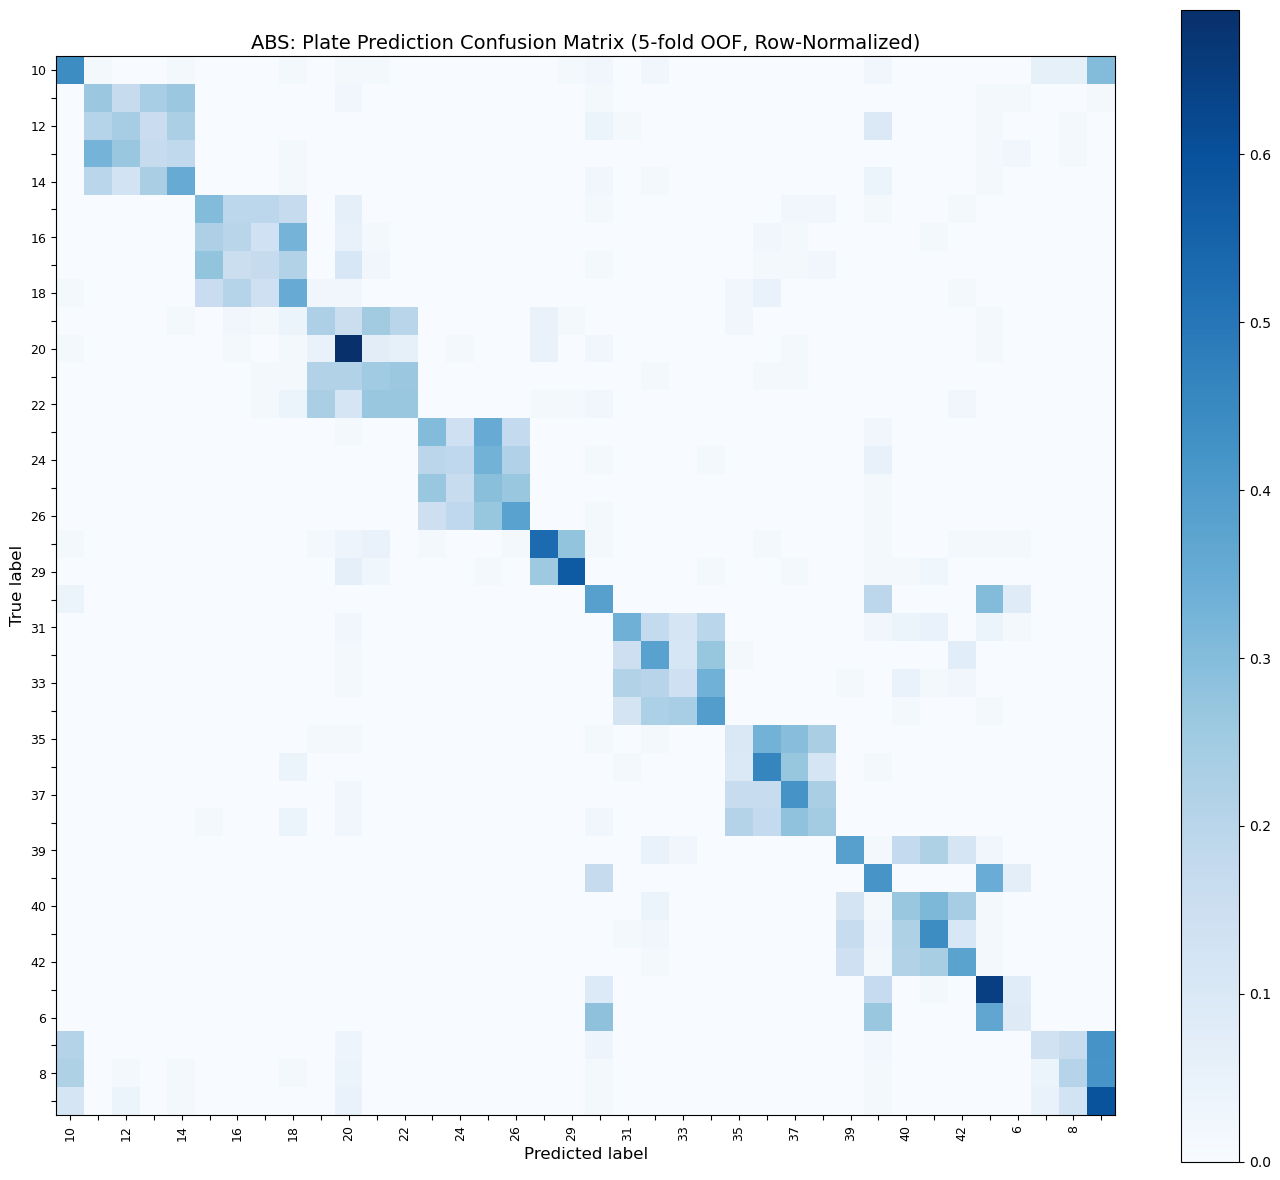

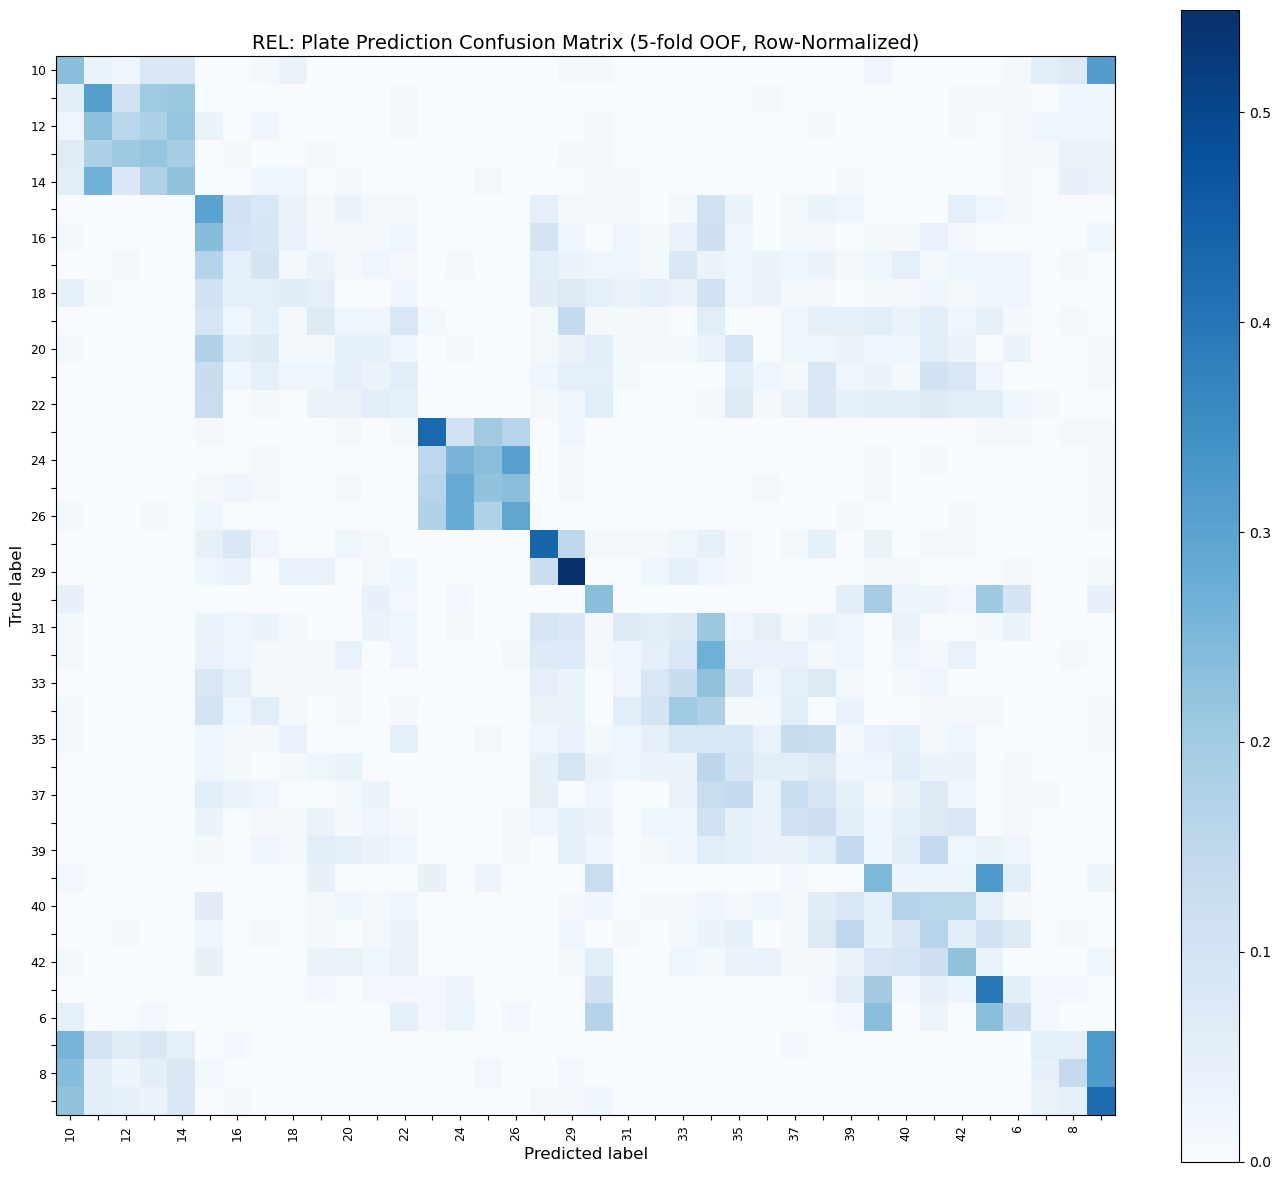

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score
)

# 0. Helper: build X, y for plate prediction
def build_plate_xy(df, plate_col="sample_plate"):
    df = df.copy()

    # keep valid plate
    df = df.dropna(subset=[plate_col])

    # merge "_diluted" with base plate by extracting the plate number
    # e.g., "NPH_15288_Plate_10_diluted" -> "10"
    df["plate_number"] = df[plate_col].astype(str).str.extract(r"Plate_(\d+)")

    # drop rows where extraction failed
    df = df.dropna(subset=["plate_number"])
    df["plate_number"] = df["plate_number"].astype(str)  # keep as class label

    # features (G* columns)
    feature_cols = [c for c in df.columns if c.startswith("G")]
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    y = df["plate_number"]
    return X, y


def majority_baseline_acc(y):
    # accuracy if always predict the most common class
    return y.value_counts(normalize=True).max()


def plot_plate_confusion_matrix(y_true, y_pred, labels, title, step=2, normalize="true"):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)

    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        include_values=False,
        colorbar=True
    )

    # reduce tick density if too crowded
    xticks = ax.get_xticklabels()
    yticks = ax.get_yticklabels()

    for i, label in enumerate(xticks):
        if i % step != 0:
            label.set_visible(False)

    for i, label in enumerate(yticks):
        if i % step != 0:
            label.set_visible(False)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)
    ax.tick_params(axis="both", labelsize=9)

    plt.tight_layout()
    plt.show()


# 1. Combine splits
abs_all = pd.concat([abs_train, abs_val, abs_test], axis=0, ignore_index=True)
rel_all = pd.concat([rel_train, rel_val, rel_test], axis=0, ignore_index=True)

# 2. Build X,y for ABS and REL
X_abs, y_abs = build_plate_xy(abs_all, plate_col="sample_plate")
X_rel, y_rel = build_plate_xy(rel_all, plate_col="sample_plate")

print("ABS X shape:", X_abs.shape, "| #plates:", y_abs.nunique())
print("REL X shape:", X_rel.shape, "| #plates:", y_rel.nunique())

# 3. Baseline
print("ABS baseline (majority class accuracy):", majority_baseline_acc(y_abs))
print("REL baseline (majority class accuracy):", majority_baseline_acc(y_rel))

# 4. CV training (Accuracy + Balanced Accuracy)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"acc": "accuracy", "bal_acc": "balanced_accuracy"}

abs_scores = cross_validate(rf, X_abs, y_abs, cv=cv, scoring=scoring, n_jobs=-1)
rel_scores = cross_validate(rf, X_rel, y_rel, cv=cv, scoring=scoring, n_jobs=-1)

print("\nABS CV accuracy:", abs_scores["test_acc"].mean())
print("ABS CV balanced accuracy:", abs_scores["test_bal_acc"].mean())

print("\nREL CV accuracy:", rel_scores["test_acc"].mean())
print("REL CV balanced accuracy:", rel_scores["test_bal_acc"].mean())

# 5. Confusion matrix (OUT-OF-FOLD predictions, not train-fit)

# ABS
y_pred_abs_oof = cross_val_predict(rf, X_abs, y_abs, cv=cv, n_jobs=-1)
labels_abs = sorted(y_abs.unique())

plot_plate_confusion_matrix(
    y_true=y_abs,
    y_pred=y_pred_abs_oof,
    labels=labels_abs,
    title="ABS: Plate Prediction Confusion Matrix (5-fold OOF, Row-Normalized)",
    step=2,
    normalize="true"
)

# REL
y_pred_rel_oof = cross_val_predict(rf, X_rel, y_rel, cv=cv, n_jobs=-1)
labels_rel = sorted(y_rel.unique())

plot_plate_confusion_matrix(
    y_true=y_rel,
    y_pred=y_pred_rel_oof,
    labels=labels_rel,
    title="REL: Plate Prediction Confusion Matrix (5-fold OOF, Row-Normalized)",
    step=2,
    normalize="true"
)

### 2.2 Test using total count * relative abundance

In [23]:
base_path = "/ddn_scratch/k5zhao/data/model_training"

train_df = pd.read_csv(f"{base_path}/train.csv")
val_df   = pd.read_csv(f"{base_path}/val.csv")
test_df  = pd.read_csv(f"{base_path}/test.csv")

Baseline (majority acc): 0.027938342967244702
CV accuracy: 0.20359220244331705
CV balanced accuracy: 0.20408840729274166


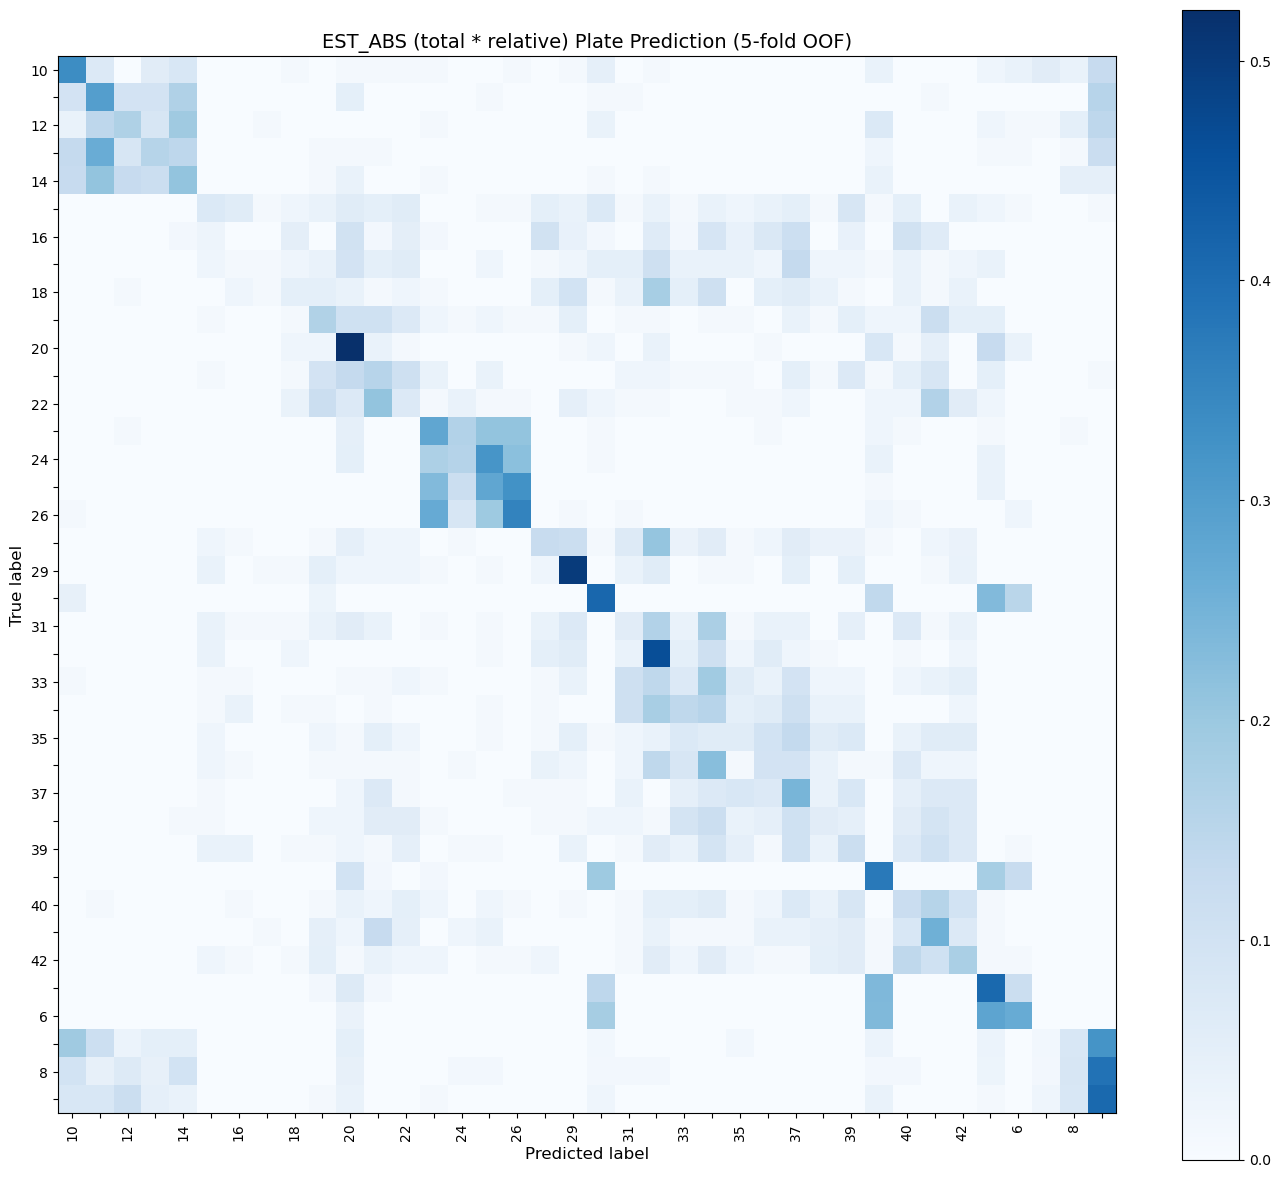

In [24]:
def make_estimated_absolute(rel_df, total_df, total_col="total", plate_col="sample_plate"):
    g_cols = [c for c in rel_df.columns if c.startswith("G")]
    if total_col not in total_df.columns:
        raise ValueError(f"Missing `{total_col}` in total_df.")
    if len(rel_df) != len(total_df):
        raise ValueError("rel_df and total_df must have the same number of rows (aligned samples).")

    rel_g = rel_df[g_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    totals = pd.to_numeric(total_df[total_col], errors="coerce").fillna(0.0)

    est_abs = rel_g.mul(totals, axis=0)
    if plate_col in rel_df.columns:
        est_abs[plate_col] = rel_df[plate_col].values
    elif plate_col in total_df.columns:
        est_abs[plate_col] = total_df[plate_col].values

    return est_abs


# combine splits
abs_all = pd.concat([train_df, val_df, test_df], ignore_index=True)
rel_all = pd.concat([rel_train, rel_val, rel_test], ignore_index=True)

# estimated absolute table
est_abs_all = make_estimated_absolute(rel_all, abs_all, total_col="total", plate_col="sample_plate")

# plate diagnosis (reusing your existing helpers)
X_est, y_est = build_plate_xy(est_abs_all, plate_col="sample_plate")

print("Baseline (majority acc):", majority_baseline_acc(y_est))

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    rf, X_est, y_est, cv=cv,
    scoring={"acc": "accuracy", "bal_acc": "balanced_accuracy"},
    n_jobs=-1
)

print("CV accuracy:", scores["test_acc"].mean())
print("CV balanced accuracy:", scores["test_bal_acc"].mean())


# OOF confusion matrix
y_pred = cross_val_predict(rf, X_est, y_est, cv=cv, n_jobs=-1)
labels = sorted(y_est.unique())

cm = confusion_matrix(y_est, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    include_values=False,
    colorbar=True
)

# reduce tick density
step = 2
for i, label in enumerate(ax.get_xticklabels()):
    if i % step != 0:
        label.set_visible(False)

for i, label in enumerate(ax.get_yticklabels()):
    if i % step != 0:
        label.set_visible(False)

ax.set_title("EST_ABS (total * relative) Plate Prediction (5-fold OOF)", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

plt.tight_layout()
plt.show()

## 3. Modeling Pipelines with Bootstrap Significance Testing

### 3.1 Baseline models

In [17]:
#!/usr/bin/env python3
"""
Baseline Models for Three Tasks

Tasks
-----
1. BMI regression
   - Baseline: predict training-set mean BMI

2. BMI classification
   - Baseline: predict majority BMI bin from training set

3. Stool quality classification
   - Baseline: predict majority stool class from training set

This script evaluates baselines on validation and test splits.
"""

import os
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    accuracy_score,
    f1_score,
)

DEFAULT_DATA_DIR = "/ddn_scratch/k5zhao/data/classifier_training"

def load_data(data_dir=None):
    data_dir = data_dir or os.environ.get("DATA_DIR", DEFAULT_DATA_DIR)

    abs_train = pd.read_csv(os.path.join(data_dir, "abs_train.csv"), low_memory=False)
    abs_val   = pd.read_csv(os.path.join(data_dir, "abs_val.csv"), low_memory=False)
    abs_test  = pd.read_csv(os.path.join(data_dir, "abs_test.csv"), low_memory=False)

    rel_train = pd.read_csv(os.path.join(data_dir, "rel_train.csv"), low_memory=False)
    rel_val   = pd.read_csv(os.path.join(data_dir, "rel_val.csv"), low_memory=False)
    rel_test  = pd.read_csv(os.path.join(data_dir, "rel_test.csv"), low_memory=False)

    return abs_train, abs_val, abs_test, rel_train, rel_val, rel_test

def add_bmi_bin(df):
    df = df.copy()
    df["bmi_bin"] = pd.cut(
        df["bmi"],
        bins=[0, 18.5, 25, 30, 40, 1000],
        right=False,
        labels=["under", "normal", "over", "obese", "severe_obese"]
    )
    return df


def clean_bowel_movement(df):
    df = df.copy()

    raw = df["bowel_movement"].astype(str).str.strip().str.strip('"')

    mapping = {
        "I had normal formed stool, and my stool looks like Type 3 and/or 4": "normal",
        "I had diarrhea (watery stool), and my stool looks like Type 5, 6, and/or 7": "diarrhea",
        "I was constipated (had difficulty passing stool), and my stool looks like Type 1 and/or 2": "constipated",
    }

    df["bowel_movement_clean"] = raw.map(mapping)
    return df


# Baseline evaluators
def evaluate_regression_baseline(y_train, y_val, y_test):
    baseline_value = float(np.mean(y_train))

    val_pred = np.full(len(y_val), baseline_value)
    test_pred = np.full(len(y_test), baseline_value)

    results = {
        "Baseline_Value": baseline_value,
        "Val_MAE": mean_absolute_error(y_val, val_pred),
        "Test_MAE": mean_absolute_error(y_test, test_pred),
        "Val_R2": r2_score(y_val, val_pred),
        "Test_R2": r2_score(y_test, test_pred),
    }
    return results


def evaluate_classification_baseline(y_train, y_val, y_test):
    majority_class = pd.Series(y_train).value_counts().idxmax()

    val_pred = np.array([majority_class] * len(y_val))
    test_pred = np.array([majority_class] * len(y_test))

    results = {
        "Majority_Class": majority_class,
        "Val_Accuracy": accuracy_score(y_val, val_pred),
        "Test_Accuracy": accuracy_score(y_test, test_pred),
        "Val_MacroF1": f1_score(y_val, val_pred, average="macro"),
        "Test_MacroF1": f1_score(y_test, test_pred, average="macro"),
        "Val_WeightedF1": f1_score(y_val, val_pred, average="weighted"),
        "Test_WeightedF1": f1_score(y_test, test_pred, average="weighted"),
    }
    return results


def main():
    abs_train, abs_val, abs_test, rel_train, rel_val, rel_test = load_data()

    # 1. BMI regression baseline
    bmi_reg_results = evaluate_regression_baseline(
        y_train=abs_train["bmi"].values,
        y_val=abs_val["bmi"].values,
        y_test=abs_test["bmi"].values,
    )

    print("\n==============================")
    print("BMI Regression Baseline")
    print("==============================")
    print(f"Train mean BMI: {bmi_reg_results['Baseline_Value']:.4f}")
    print(f"Validation MAE: {bmi_reg_results['Val_MAE']:.4f}")
    print(f"Test MAE: {bmi_reg_results['Test_MAE']:.4f}")
    print(f"Validation R²: {bmi_reg_results['Val_R2']:.4f}")
    print(f"Test R²: {bmi_reg_results['Test_R2']:.4f}")

    # 2. BMI classification baseline
    abs_train_bmi = add_bmi_bin(abs_train)
    abs_val_bmi   = add_bmi_bin(abs_val)
    abs_test_bmi  = add_bmi_bin(abs_test)

    bmi_cls_results = evaluate_classification_baseline(
        y_train=abs_train_bmi["bmi_bin"].values,
        y_val=abs_val_bmi["bmi_bin"].values,
        y_test=abs_test_bmi["bmi_bin"].values,
    )

    print("\n==============================")
    print("BMI Classification Baseline")
    print("==============================")
    print(f"Majority class: {bmi_cls_results['Majority_Class']}")
    print(f"Validation Accuracy: {bmi_cls_results['Val_Accuracy']:.4f}")
    print(f"Test Accuracy: {bmi_cls_results['Test_Accuracy']:.4f}")
    print(f"Validation Macro F1: {bmi_cls_results['Val_MacroF1']:.4f}")
    print(f"Test Macro F1: {bmi_cls_results['Test_MacroF1']:.4f}")
    print(f"Validation Weighted F1: {bmi_cls_results['Val_WeightedF1']:.4f}")
    print(f"Test Weighted F1: {bmi_cls_results['Test_WeightedF1']:.4f}")

    # 3. Stool classification baseline
    abs_train_stool = clean_bowel_movement(abs_train)
    abs_val_stool   = clean_bowel_movement(abs_val)
    abs_test_stool  = clean_bowel_movement(abs_test)

    abs_train_stool = abs_train_stool.dropna(subset=["bowel_movement_clean"]).copy()
    abs_val_stool   = abs_val_stool.dropna(subset=["bowel_movement_clean"]).copy()
    abs_test_stool  = abs_test_stool.dropna(subset=["bowel_movement_clean"]).copy()

    stool_cls_results = evaluate_classification_baseline(
        y_train=abs_train_stool["bowel_movement_clean"].values,
        y_val=abs_val_stool["bowel_movement_clean"].values,
        y_test=abs_test_stool["bowel_movement_clean"].values,
    )

    print("\n==============================")
    print("Stool Classification Baseline")
    print("==============================")
    print(f"Majority class: {stool_cls_results['Majority_Class']}")
    print(f"Validation Accuracy: {stool_cls_results['Val_Accuracy']:.4f}")
    print(f"Test Accuracy: {stool_cls_results['Test_Accuracy']:.4f}")
    print(f"Validation Macro F1: {stool_cls_results['Val_MacroF1']:.4f}")
    print(f"Test Macro F1: {stool_cls_results['Test_MacroF1']:.4f}")
    print(f"Validation Weighted F1: {stool_cls_results['Val_WeightedF1']:.4f}")
    print(f"Test Weighted F1: {stool_cls_results['Test_WeightedF1']:.4f}")


if __name__ == "__main__":
    main()


BMI Regression Baseline
Train mean BMI: 28.8241
Validation MAE: 5.2018
Test MAE: 5.4371
Validation R²: -0.0021
Test R²: -0.0004

BMI Classification Baseline
Majority class: normal
Validation Accuracy: 0.3312
Test Accuracy: 0.3046
Validation Macro F1: 0.0995
Test Macro F1: 0.0934
Validation Weighted F1: 0.1648
Test Weighted F1: 0.1422

Stool Classification Baseline
Majority class: normal
Validation Accuracy: 0.5994
Test Accuracy: 0.6226
Validation Macro F1: 0.2498
Test Macro F1: 0.2558
Validation Weighted F1: 0.4492
Test Weighted F1: 0.4778


### 3.2 Complete model pipelines

In [10]:
#!/usr/bin/env python3
"""
BMI Classification Pipeline

Purpose
-------
Train classifiers to predict BMI category (bmi_bin) from microbiome features
using two abundance data:
    1. Absolute abundance
    2. Relative abundance

Pipeline Steps
--------------
1. Load train / validation / test datasets.
2. Create `bmi_bin` from continuous BMI using predefined bins.
3. Preprocess microbiome features:
      - keep columns starting with "G"
      - apply prevalence filter on TRAIN only
      - apply log10(x + 1) transform
4. Train models on Absolute and Relative data:
      - RandomForest
      - HistGradientBoosting (with grid search)
      - SVM (RBF kernel with grid search)
5. Evaluate models using:
      - Accuracy
      - Macro / Weighted F1
      - R² (computed on encoded labels)
6. Generate plots:
      - Confusion matrices
      - Multiclass ROC curves
7. Save metrics and plots to disk.

Output
------
The pipeline saves results to the directories specified by environment variables
(or their default locations).

Files generated:
    CONF_DIR/
        bmi_bin_Absolute_<model>_confusion.png
        bmi_bin_Relative_<model>_confusion.png
        cls_bmi_results_<model>.csv

    ROC_DIR/
        bmi_bin_Absolute_<model>_roc.png
        bmi_bin_Relative_<model>_roc.png

    MODEL_DIR/
        bmi_bin_Absolute_<model>.joblib
        bmi_bin_Relative_<model>.joblib

Usage
-----
Run all models:
    python bmi_classification.py

Run a single model:
    python bmi_classification.py --model RandomForest
    python bmi_classification.py --model HGB
    python bmi_classification.py --model SVM_RBF

Optional environment variables:
    DATA_DIR    path to input CSV files
    CONF_DIR    folder for confusion matrices
    ROC_DIR     folder for ROC plots
    MODEL_DIR   folder for saved trained models

Example with all variables:
    DATA_DIR="/ddn_scratch/k5zhao/data/classifier_training" \
    CONF_DIR="/home/zhw074/bmi_bin/confusion" \
    ROC_DIR="/home/zhw074/bmi_bin/roc_plots" \
    MODEL_DIR="/home/zhw074/bmi_bin/models" \
    python bmi_classification.py --model HGB
"""

import os
import argparse
import pandas as pd
import numpy as np
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, label_binarize

DEFAULT_DATA_DIR = "/ddn_scratch/k5zhao/data/classifier_training"
DEFAULT_CONF_DIR = "/home/zhw074/bmi_bin/confusion"
DEFAULT_ROC_DIR  = "/home/zhw074/bmi_bin/roc_plots"
DEFAULT_MODEL_DIR = "/home/zhw074/bmi_bin/models"

def load_data(data_dir=None):
    """
    Load abs/rel train/val/test CSVs.

    Expects:
      abs_train.csv, abs_val.csv, abs_test.csv,
      rel_train.csv, rel_val.csv, rel_test.csv
    under data_dir.
    """
    data_dir = data_dir or os.environ.get("DATA_DIR", DEFAULT_DATA_DIR)

    abs_train = pd.read_csv(os.path.join(data_dir, "abs_train.csv"), low_memory=False)
    abs_val   = pd.read_csv(os.path.join(data_dir, "abs_val.csv"), low_memory=False)
    abs_test  = pd.read_csv(os.path.join(data_dir, "abs_test.csv"), low_memory=False)

    rel_train = pd.read_csv(os.path.join(data_dir, "rel_train.csv"), low_memory=False)
    rel_val   = pd.read_csv(os.path.join(data_dir, "rel_val.csv"), low_memory=False)
    rel_test  = pd.read_csv(os.path.join(data_dir, "rel_test.csv"), low_memory=False)

    return abs_train, abs_val, abs_test, rel_train, rel_val, rel_test

def preprocess_representation(train_df, val_df, test_df, prevalence_thresh):
    """
    - Use only columns starting with "G"
    - Prevalence filter computed ONLY on train
    - log10(x + 1)
    """
    feature_cols = [c for c in train_df.columns if c.startswith("G")]

    X_train_raw = train_df[feature_cols]
    X_val_raw   = val_df[feature_cols]
    X_test_raw  = test_df[feature_cols]

    keep_mask = (X_train_raw > 0).mean(axis=0) >= prevalence_thresh

    X_train = np.log10(X_train_raw.loc[:, keep_mask] + 1)
    X_val   = np.log10(X_val_raw.loc[:, keep_mask] + 1)
    X_test  = np.log10(X_test_raw.loc[:, keep_mask] + 1)

    return X_train, X_val, X_test


def add_bmi_bin(df):
    df = df.copy()
    df["bmi_bin"] = pd.cut(
        df["bmi"],
        bins=[0, 18.5, 25, 30, 40, 1000],
        right=False,
        labels=["under", "normal", "over", "obese", "severe_obese"]
    )
    return df


def run_classification_experiments(
    target_col,
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.4,
    selected_model="all",
    model_dir=None,
):
    classifiers = {
        "RandomForest": {
            "model": RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                random_state=42,
                n_jobs=-1,
                verbose=1
            ),
            "param_grid": None,
        },
        "HGB": {
            "model": HistGradientBoostingClassifier(
                max_depth=8,
                learning_rate=0.05,
                max_iter=300,
                random_state=42,
                verbose=1
            ),
            "param_grid": {
                "max_depth": [6, 8, 10],
                "learning_rate": [0.05, 0.1],
            },
        },
        "SVM_RBF": {
            "model": SVC(
                kernel="rbf",
                C=10.0,
                gamma="scale",
                probability=True,
                verbose=True
            ),
            "param_grid": {
                "C": [1.0, 10.0, 100.0],
                "gamma": ["scale", "auto"],
            },
        },
    }

    # ---- model switch (all vs single) ----
    if selected_model != "all":
        if selected_model not in classifiers:
            raise ValueError(f"selected_model must be one of {['all'] + list(classifiers.keys())}")
        classifiers = {selected_model: classifiers[selected_model]}

    reps = {
        "Absolute": (abs_train, abs_val, abs_test),
        "Relative": (rel_train, rel_val, rel_test),
    }

    all_results = []
    best_models = {}
    best_params_summary = {}

    if model_dir is not None:
        os.makedirs(model_dir, exist_ok=True)

    for rep_name, (train_df, val_df, test_df) in reps.items():

        print(f"\n=== Representation: {rep_name} ===")

        X_tr, X_va, X_te = preprocess_representation(
            train_df, val_df, test_df,
            prevalence_thresh=prevalence_thresh
        )

        y_tr = train_df[target_col].values
        y_va = val_df[target_col].values
        y_te = test_df[target_col].values

        # Encode labels numerically for R²
        le = LabelEncoder()
        y_tr_enc = le.fit_transform(y_tr)
        y_va_enc = le.transform(y_va)
        y_te_enc = le.transform(y_te)

        for model_name, info in classifiers.items():
            base_model = info["model"]
            param_grid = info["param_grid"]

            print(f">>> Training {model_name} on {rep_name} ...")

            if param_grid is not None:
                gs = GridSearchCV(
                    estimator=clone(base_model),
                    param_grid=param_grid,
                    cv=3,
                    scoring="accuracy",
                    n_jobs=-1,
                    verbose=1
                )
                gs.fit(X_tr, y_tr)
                model = gs.best_estimator_
                print(f"Best parameters: {gs.best_params_}")
                best_params_summary[(rep_name, model_name)] = gs.best_params_
            else:
                model = clone(base_model)
                model.fit(X_tr, y_tr)
                best_params_summary[(rep_name, model_name)] = "default parameters"

            best_models[(rep_name, model_name)] = model
            best_models[(rep_name, model_name, "X_te")] = X_te
            best_models[(rep_name, model_name, "y_te")] = y_te

            if model_dir is not None:
                model_path = os.path.join(model_dir, f"{target_col}_{rep_name}_{model_name}.joblib")
                joblib.dump(model, model_path)

            # Validation predictions
            y_va_pred = model.predict(X_va)
            val_acc = accuracy_score(y_va, y_va_pred)
            val_f1_macro = f1_score(y_va, y_va_pred, average="macro")
            val_f1_weighted = f1_score(y_va, y_va_pred, average="weighted")

            # Encode predictions for R²
            y_va_pred_enc = le.transform(y_va_pred)
            val_r2 = r2_score(y_va_enc, y_va_pred_enc)

            # Test predictions
            y_te_pred = model.predict(X_te)
            test_acc = accuracy_score(y_te, y_te_pred)
            test_f1_macro = f1_score(y_te, y_te_pred, average="macro")
            test_f1_weighted = f1_score(y_te, y_te_pred, average="weighted")

            y_te_pred_enc = le.transform(y_te_pred)
            test_r2 = r2_score(y_te_enc, y_te_pred_enc)

            all_results.append({
                "Task": "Classification",
                "Target": target_col,
                "Representation": rep_name,
                "Model": model_name,
                "Prevalence": prevalence_thresh,
                "Val_Accuracy": val_acc,
                "Test_Accuracy": test_acc,
                "Val_MacroF1": val_f1_macro,
                "Test_MacroF1": test_f1_macro,
                "Val_WeightedF1": val_f1_weighted,
                "Test_WeightedF1": test_f1_weighted,
                "Val_R2": val_r2,
                "Test_R2": test_r2,
            })

    results_df = pd.DataFrame(all_results)
    return results_df, best_models, best_params_summary

# plotting
def plot_cached_classification_results(
    best_models,
    target_col,
    reps=("Absolute", "Relative"),
    models=("RandomForest", "HGB", "SVM_RBF"),
    normalize="true",
    save_dir=None,
):
    """Plot confusion matrices for cached classification models."""
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for rep_name in reps:
        for model_name in models:
            key_model = (rep_name, model_name)
            key_X = (rep_name, model_name, "X_te")
            key_y = (rep_name, model_name, "y_te")

            model = best_models.get(key_model)
            X_te = best_models.get(key_X)
            y_te = best_models.get(key_y)

            if model is None or X_te is None or y_te is None:
                print(f"[skip] No model or test data for {rep_name} - {model_name}")
                continue

            y_pred = model.predict(X_te)

            acc = accuracy_score(y_te, y_pred)
            macro_f1 = f1_score(y_te, y_pred, average="macro")

            fig, ax = plt.subplots(figsize=(4, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_te,
                y_pred,
                normalize=normalize,
                cmap="Blues",
                colorbar=False,
                ax=ax,
            )
            ax.set_title(
                f"{target_col} | {rep_name} - {model_name}\n"
                f"Acc = {acc:.3f}, Macro F1 = {macro_f1:.3f}"
            )
            plt.tight_layout()

            if save_dir is None:
                plt.show()
            else:
                fname = f"{target_col}_{rep_name}_{model_name}_confusion.png"
                plt.savefig(os.path.join(save_dir, fname), dpi=200, bbox_inches="tight")
                plt.close()


def plot_cached_multiclass_roc(
    best_models,
    target_col,
    reps=("Absolute", "Relative"),
    models=("RandomForest", "HGB", "SVM_RBF"),
    save_dir=None,
):
    """Plot one-vs-rest ROC curves and macro AUC for cached classification models."""
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for rep_name in reps:
        for model_name in models:
            key_model = (rep_name, model_name)
            key_X = (rep_name, model_name, "X_te")
            key_y = (rep_name, model_name, "y_te")

            model = best_models.get(key_model)
            X_te = best_models.get(key_X)
            y_te = best_models.get(key_y)

            if model is None or X_te is None or y_te is None:
                print(f"[skip] No model or test data for {rep_name} - {model_name}")
                continue

            # Need probability estimates for ROC
            if not hasattr(model, "predict_proba"):
                print(f"[skip] {rep_name} - {model_name} (no predict_proba)")
                continue

            probs = model.predict_proba(X_te)
            classes = model.classes_
            y_bin = label_binarize(y_te, classes=classes)

            plt.figure(figsize=(4.5, 4))
            aucs = []

            for i, cls in enumerate(classes):
                fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
                roc_auc = auc(fpr, tpr)
                aucs.append(roc_auc)
                plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})", linewidth=1.2)

            plt.plot([0, 1], [0, 1], "k--", linewidth=1)

            macro_auc = float(np.mean(aucs))
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(
                f"{target_col} ROC | {rep_name} - {model_name}\n"
                f"Macro AUC = {macro_auc:.3f}"
            )
            plt.legend(fontsize=7)
            plt.tight_layout()

            if save_dir is None:
                plt.show()
            else:
                fname = f"{target_col}_{rep_name}_{model_name}_roc.png"
                plt.savefig(os.path.join(save_dir, fname), dpi=200, bbox_inches="tight")
                plt.close()


def bootstrap_classification_test(y_true, pred_abs, pred_rel,
                                  prob_abs=None, prob_rel=None,
                                  n_boot=10000):

    rng = np.random.default_rng(42)
    n = len(y_true)

    acc_diffs = []
    auc_diffs = []

    for _ in range(n_boot):

        idx = rng.choice(n, n, replace=True)

        y_sample = y_true[idx]
        abs_sample = pred_abs[idx]
        rel_sample = pred_rel[idx]

        acc_abs = accuracy_score(y_sample, abs_sample)
        acc_rel = accuracy_score(y_sample, rel_sample)

        acc_diffs.append(acc_rel - acc_abs)

        if prob_abs is not None:
            try:
                auc_abs = roc_auc_score(y_sample, prob_abs[idx], multi_class="ovr")
                auc_rel = roc_auc_score(y_sample, prob_rel[idx], multi_class="ovr")

                auc_diffs.append(auc_rel - auc_abs)

            except ValueError:
                # happens if bootstrap sample missing classes
                continue

    acc_diffs = np.array(acc_diffs)

    print("\nBOOTSTRAP RESULTS")
    print("------------------")
    print("ΔAccuracy:", acc_diffs.mean())
    print("95% CI:", np.percentile(acc_diffs, [2.5,97.5]))
    print("p-value:", 2*min(np.mean(acc_diffs<=0),np.mean(acc_diffs>=0)))

    if len(auc_diffs) > 0:
        auc_diffs = np.array(auc_diffs)
        print("\nΔROC-AUC:", auc_diffs.mean())
        print("95% CI:", np.percentile(auc_diffs,[2.5,97.5]))
        print("p-value:",2*min(np.mean(auc_diffs<=0),np.mean(auc_diffs>=0)))                

        
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--model",
        default="all",
        choices=["all", "RandomForest", "HGB", "SVM_RBF"],
        help="Choose which model(s) to run."
    )
    parser.add_argument(
        "--prevalence",
        type=float,
        default=0.4,
        help="Prevalence threshold for feature filtering (default: 0.4)."
    )
    parser.add_argument(
        "--normalize",
        default="true",
        choices=["true", "pred", "all", None],
        help="Confusion matrix normalization (sklearn normalize=)."
    )
    args = parser.parse_args(args=[])
    
    # Load abs/rel
    abs_train, abs_val, abs_test, rel_train, rel_val, rel_test = load_data()

    # Add bmi_bin exactly like notebook
    abs_train = add_bmi_bin(abs_train)
    abs_val   = add_bmi_bin(abs_val)
    abs_test  = add_bmi_bin(abs_test)

    rel_train = add_bmi_bin(rel_train)
    rel_val   = add_bmi_bin(rel_val)
    rel_test  = add_bmi_bin(rel_test)

    # Print counts like your notebook (helps sanity check on cluster logs)
    print("\n[abs_train bmi_bin counts]")
    print(abs_train["bmi_bin"].value_counts(dropna=False))

    # Output dirs (defaults match your notebook)
    conf_dir = os.environ.get("CONF_DIR", DEFAULT_CONF_DIR)
    roc_dir  = os.environ.get("ROC_DIR", DEFAULT_ROC_DIR)
    model_dir = os.environ.get("MODEL_DIR", DEFAULT_MODEL_DIR)

    # Run experiments
    cls_bmi_results, cls_bmi_models, best_params_summary = run_classification_experiments(
        target_col="bmi_bin",
        abs_train=abs_train,
        abs_val=abs_val,
        abs_test=abs_test,
        rel_train=rel_train,
        rel_val=rel_val,
        rel_test=rel_test,
        prevalence_thresh=args.prevalence,
        selected_model=args.model,
        model_dir=model_dir
    )

    # Plot only the requested model(s)
    if args.model == "all":
        plot_models = ("RandomForest", "HGB", "SVM_RBF")
    else:
        plot_models = (args.model,)

    plot_cached_classification_results(
        best_models=cls_bmi_models,
        target_col="bmi_bin",
        models=plot_models,
        normalize=args.normalize,
        save_dir=conf_dir
    )

    plot_cached_multiclass_roc(
        best_models=cls_bmi_models,
        target_col="bmi_bin",
        models=plot_models,
        save_dir=roc_dir
    )

    # Save metrics table (handy for batch runs)
    os.makedirs(conf_dir, exist_ok=True)
    os.makedirs(roc_dir, exist_ok=True)
    os.makedirs(model_dir, exist_ok=True)

    out_csv = os.path.join(conf_dir, f"cls_bmi_results_{args.model}.csv")
    cls_bmi_results.to_csv(out_csv, index=False)

    # Bootstrap significance tests
    print("\nRunning bootstrap significance tests...")

    models = ("RandomForest","HGB","SVM_RBF")

    for m in models:

        try:

            model_abs = cls_bmi_models[("Absolute",m)]
            model_rel = cls_bmi_models[("Relative",m)]

            X_abs = cls_bmi_models[("Absolute",m,"X_te")]
            X_rel = cls_bmi_models[("Relative",m,"X_te")]

            y = cls_bmi_models[("Absolute",m,"y_te")]

            pred_abs = model_abs.predict(X_abs)
            pred_rel = model_rel.predict(X_rel)

            prob_abs = None
            prob_rel = None

            if hasattr(model_abs,"predict_proba"):
                prob_abs = model_abs.predict_proba(X_abs)
                prob_rel = model_rel.predict_proba(X_rel)

            print(f"\n=== Bootstrap test: {m} ===")

            bootstrap_classification_test(
                y_true=np.array(y),
                pred_abs=np.array(pred_abs),
                pred_rel=np.array(pred_rel),
                prob_abs=prob_abs,
                prob_rel=prob_rel
            )

        except KeyError:
            print(f"Skipping {m} (model not run)")
    
    print("\nSaved confusion matrices to:", conf_dir)
    print("Saved ROC plots to:", roc_dir)
    print("Saved models to:", model_dir)
    print("Saved metrics to:", out_csv)

    print("\nBest hyperparameters for each model")
    print("------------------------------------")
    for (rep, model), params in best_params_summary.items():
        print(f"{rep} - {model}: {params}")

    print("\nResults preview:")
    print(cls_bmi_results)


if __name__ == "__main__":
    main()


[abs_train bmi_bin counts]
bmi_bin
normal          625
over            603
obese           490
severe_obese    165
under            27
Name: count, dtype: int64

=== Representation: Absolute ===
>>> Training RandomForest on Absolute ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    1.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s


>>> Training HGB on Absolute ...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: 0.516 s
Fitting gradient boosted rounds:
[1/300] 0.527 s
Fitting gradient boosted rounds:
[1/300] 0.529 s
Fitting gradient boosted rounds:
[1/300] 0.529 s
Fitting gradient boosted rounds:
[1/300] 0.529 s
Fitting gradient boosted rounds:
[1/300] 0.533 s
Fitting gradient boosted rounds:
[1/300] 0.532 s
Fitting gradient boosted rounds:
[1/300] 0.540 s
Fitting gradient boosted rounds:
[1/300] 0.534 s
Fitting gradient boosted rounds:
[1/300] 0.547 s
Fitting gradient boosted rounds:
[1/300] 0.570 s
Fitting gradient boosted rounds:
[1/300] 0.582 s
Fitting gradient boosted rounds:


...

>>> Training HGB on Relative ...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
5 trees, 68 leaves (13 on avg), max depth = 8, in 0.203s
Fit 1500 trees in 110.200 s, (35990 total leaves)
Time spent computing histograms: 48.729s
Time spent finding best splits:  53.579s
Time spent applying splits:      1.977s
Time spent predicting:           0.078s
[LibSVM][LibSVM]Binning 0.009 GB of training data: 5 trees, 14 leaves (2 on avg), max depth = 3, in 0.036s
Fit 1500 trees in 68.344 s, (23103 total leaves)
Time spent computing histograms: 32.430s
Time spent finding best splits:  30.895s
Time spent applying splits:      1.155s
Time spent predicting:           0.064s
[LibSVM]Binning 0.009 GB of training data: 5 trees, 12 leaves (2 on avg), max depth = 3, in 0.025s
Fit 1500 trees in 61.558 s, (22136 total leaves)
Time spent computing histograms: 27.917s
Time spent finding best splits:  29.041s
Time spent applying splits:      1.123s
Time spent predicting:           0.056s
[LibSVM]Bi

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Do


Running bootstrap significance tests...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Do


=== Bootstrap test: RandomForest ===

BOOTSTRAP RESULTS
------------------
ΔAccuracy: 0.01575274725274725
95% CI: [-0.02040816  0.05180534]
p-value: 0.4116

ΔROC-AUC: 0.016609275675979935
95% CI: [-0.03167121  0.06355667]
p-value: 0.47942325022529286

=== Bootstrap test: HGB ===

BOOTSTRAP RESULTS
------------------
ΔAccuracy: 0.05215180533751961
95% CI: [0.01098901 0.09419152]
p-value: 0.0128

ΔROC-AUC: 0.056262613915458226
95% CI: [0.01785502 0.09707974]
p-value: 0.0034044257534795236

=== Bootstrap test: SVM_RBF ===

BOOTSTRAP RESULTS
------------------
ΔAccuracy: 0.04248037676609105
95% CI: [0.00156986 0.08320251]
p-value: 0.0442

ΔROC-AUC: 0.03543891800856955
95% CI: [-0.00178554  0.07178003]
p-value: 0.06168018423951137

Saved confusion matrices to: /home/zhw074/bmi_bin/confusion
Saved ROC plots to: /home/zhw074/bmi_bin/roc_plots
Saved models to: /home/zhw074/bmi_bin/models
Saved metrics to: /home/zhw074/bmi_bin/confusion/cls_bmi_results_all.csv

Best hyperparameters for each mo

In [11]:
#!/usr/bin/env python3
"""
BMI Regression Pipeline

Purpose
-------
Predict continuous BMI from microbiome features using two abundance tables:
    1. Absolute abundance
    2. Relative abundance

Pipeline Steps
--------------
1. Load train / validation / test datasets.
2. Preprocess microbiome features:
      - keep columns starting with "G"
      - apply prevalence filter on TRAIN only
      - apply log10(x + 1) transform
3. Train regression models on Absolute and Relative data:
      - RandomForest
      - HistGradientBoosting (with grid search)
      - SVM (RBF kernel with grid search)
4. Evaluate models using:
      - R²
      - Mean Absolute Error (MAE)
5. Generate prediction plots (True BMI vs Predicted BMI).
6. Save plots and metrics to disk.

Output
------
The pipeline saves results to the directory specified by PLOT_DIR
(or the default location if not provided).

Files generated:
    PLOT_DIR/
        bmi_Absolute_<model>.png
        bmi_Relative_<model>.png
        reg_bmi_results_<model>.csv

    MODEL_DIR/
        bmi_Absolute_<model>.joblib
        bmi_Relative_<model>.joblib
        
Usage
-----
Run all models:
    python bmi_regression.py

Run a single model:
    python bmi_regression.py --model RandomForest
    python bmi_regression.py --model HGB
    python bmi_regression.py --model SVM_RBF

Optional environment variables
    DATA_DIR    Path to input CSV files.
    PLOT_DIR    Directory where regression plots and metrics will be saved.
    MODEL_DIR   folder for saved trained models

Example with all variables:
    DATA_DIR="/ddn_scratch/k5zhao/data/classifier_training" \
    PLOT_DIR="/home/zhw074/bmi/regression_plots" \
    MODEL_DIR="/home/zhw074/bmi/models" \
    python bmi_regression.py --model HGB
"""

import os
import argparse
import pandas as pd
import numpy as np
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.svm import SVR, SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder

DEFAULT_DATA_DIR = "/ddn_scratch/k5zhao/data/classifier_training"
DEFAULT_PLOT_DIR = "/home/zhw074/bmi/regression_plots"
DEFAULT_MODEL_DIR = "/home/zhw074/bmi/models"

def load_data(data_dir=None):
    """
    Load abs/rel train/val/test CSVs.

    Expects:
      abs_train.csv, abs_val.csv, abs_test.csv,
      rel_train.csv, rel_val.csv, rel_test.csv
    under data_dir.
    """
    data_dir = data_dir or os.environ.get("DATA_DIR", DEFAULT_DATA_DIR)

    abs_train = pd.read_csv(os.path.join(data_dir, "abs_train.csv"), low_memory=False)
    abs_val   = pd.read_csv(os.path.join(data_dir, "abs_val.csv"), low_memory=False)
    abs_test  = pd.read_csv(os.path.join(data_dir, "abs_test.csv"), low_memory=False)

    rel_train = pd.read_csv(os.path.join(data_dir, "rel_train.csv"), low_memory=False)
    rel_val   = pd.read_csv(os.path.join(data_dir, "rel_val.csv"), low_memory=False)
    rel_test  = pd.read_csv(os.path.join(data_dir, "rel_test.csv"), low_memory=False)

    return abs_train, abs_val, abs_test, rel_train, rel_val, rel_test

def preprocess_representation(train_df, val_df, test_df, prevalence_thresh):
    """
    Matches your pipeline behavior:
    - Use only columns starting with "G"
    - Prevalence filter computed ONLY on train
    - log10(x + 1)
    """
    feature_cols = [c for c in train_df.columns if c.startswith("G")]

    X_train_raw = train_df[feature_cols]
    X_val_raw   = val_df[feature_cols]
    X_test_raw  = test_df[feature_cols]

    keep_mask = (X_train_raw > 0).mean(axis=0) >= prevalence_thresh

    X_train = np.log10(X_train_raw.loc[:, keep_mask] + 1)
    X_val   = np.log10(X_val_raw.loc[:, keep_mask] + 1)
    X_test  = np.log10(X_test_raw.loc[:, keep_mask] + 1)

    return X_train, X_val, X_test


def run_regression_experiments(
    target_col,
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.4,
    selected_model="all",
    model_dir=None,
):
    """
    Run regression models on absolute vs relative representations.

    - Trains RandomForest, HGB, and SVM_RBF (or a single chosen model)
    - Caches X_te and y_te for later plotting or SHAP
    - Does NOT generate or save any plots

    Returns
    -------
    results_df : pd.DataFrame
        Metrics for each (Representation, Model)

    best_models : dict
        (rep_name, model_name) -> fitted model
        (rep_name, model_name, "X_te") -> test features
        (rep_name, model_name, "y_te") -> test targets
    """

    regressors = {
        "RandomForest": {
            "model": RandomForestRegressor(
                n_estimators=300,
                max_depth=20,
                random_state=42,
                n_jobs=-1,
                verbose=1
            ),
            "param_grid": None
        },
        "HGB": {
            "model": HistGradientBoostingRegressor(
                max_depth=8,
                learning_rate=0.05,
                max_iter=300,
                random_state=42,
                verbose=1
            ),
            "param_grid": {
                "max_depth": [6, 8, 10],
                "learning_rate": [0.05, 0.1],
            }
        },
        "SVM_RBF": {
            "model": SVR(
                kernel="rbf",
                C=10.0,
                gamma="scale",
                verbose=True
            ),
            "param_grid": {
                "C": [1.0, 10.0, 100.0],
                "gamma": ["scale", "auto"],
            }
        },
    }

    # ---- filter to a single model if requested ----
    if selected_model != "all":
        if selected_model not in regressors:
            raise ValueError(f"selected_model must be one of {['all'] + list(regressors.keys())}")
        regressors = {selected_model: regressors[selected_model]}

    # Extract targets
    y_abs_train = abs_train[target_col].values
    y_abs_val   = abs_val[target_col].values
    y_abs_test  = abs_test[target_col].values

    y_rel_train = rel_train[target_col].values
    y_rel_val   = rel_val[target_col].values
    y_rel_test  = rel_test[target_col].values

    reps = {
        "Absolute": (abs_train, abs_val, abs_test, y_abs_train, y_abs_val, y_abs_test),
        "Relative": (rel_train, rel_val, rel_test, y_rel_train, y_rel_val, y_rel_test),
    }

    all_results = []
    best_models = {}
    best_params_summary = {}

    if model_dir is not None:
        os.makedirs(model_dir, exist_ok=True)

    for rep_name, (train_df, val_df, test_df, y_tr, y_va, y_te) in reps.items():

        print(f"\n=== Representation: {rep_name} ===")

        # Preprocess once per representation
        X_tr, X_va, X_te = preprocess_representation(
            train_df, val_df, test_df,
            prevalence_thresh=prevalence_thresh
        )

        for model_name, info in regressors.items():

            base_model = info["model"]
            param_grid = info["param_grid"]

            print(f"\n>>> Training {model_name} on {rep_name} ...")

            if param_grid is not None:
                gs = GridSearchCV(
                    estimator=clone(base_model),
                    param_grid=param_grid,
                    cv=3,
                    scoring="neg_mean_absolute_error",
                    n_jobs=-1,
                    verbose=2
                )
                gs.fit(X_tr, y_tr)
                model = gs.best_estimator_
                print(f"Best parameters: {gs.best_params_}")
                best_params_summary[(rep_name, model_name)] = gs.best_params_
            else:
                model = clone(base_model)
                model.fit(X_tr, y_tr)
                best_params_summary[(rep_name, model_name)] = "default parameters"

            # Cache model + test data
            best_models[(rep_name, model_name)] = model
            best_models[(rep_name, model_name, "X_te")] = X_te
            best_models[(rep_name, model_name, "y_te")] = y_te

            if model_dir is not None:
                model_path = os.path.join(model_dir, f"{target_col}_{rep_name}_{model_name}.joblib")
                joblib.dump(model, model_path)

            # Validation metrics
            y_va_pred = model.predict(X_va)
            val_r2  = r2_score(y_va, y_va_pred)
            val_mae = mean_absolute_error(y_va, y_va_pred)

            # Test metrics
            y_te_pred = model.predict(X_te)
            test_r2  = r2_score(y_te, y_te_pred)
            test_mae = mean_absolute_error(y_te, y_te_pred)

            all_results.append({
                "Task": "Regression",
                "Target": target_col,
                "Representation": rep_name,
                "Model": model_name,
                "Prevalence": prevalence_thresh,
                "Val_R2": val_r2,
                "Test_R2": test_r2,
                "Val_MAE": val_mae,
                "Test_MAE": test_mae,
            })

            print(
                f"[{rep_name} - {model_name}] "
                f"Val_R2={val_r2:.3f}, Test_R2={test_r2:.3f}, "
                f"Val_MAE={val_mae:.3f}, Test_MAE={test_mae:.3f}"
            )

    results_df = pd.DataFrame(all_results)
    return results_df, best_models, best_params_summary

# plotting
def plot_cached_regression_results(
    best_models,
    target_col,
    reps=("Absolute", "Relative"),
    models=("RandomForest", "HGB", "SVM_RBF"),
    save_dir=None,
):
    """
    Plot regression results directly from cached models and test data.

    Parameters
    ----------
    save_dir : str or Path or None
        If provided, save PNG files to this directory instead of showing inline.
    """
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for rep_name in reps:
        for model_name in models:
            key_model = (rep_name, model_name)
            key_X = (rep_name, model_name, "X_te")
            key_y = (rep_name, model_name, "y_te")

            if key_model not in best_models:
                print(f"[skip] No model found for {rep_name} - {model_name}")
                continue

            model = best_models[key_model]
            X_te = best_models[key_X]
            y_te = best_models[key_y]

            y_pred = model.predict(X_te)
            test_r2 = r2_score(y_te, y_pred)
            test_mae = mean_absolute_error(y_te, y_pred)

            plt.figure(figsize=(4, 4))
            plt.scatter(y_te, y_pred, alpha=0.4)

            lim_min = min(y_te.min(), y_pred.min())
            lim_max = max(y_te.max(), y_pred.max())
            plt.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1)

            plt.xlabel(f"True {target_col}")
            plt.ylabel(f"Predicted {target_col}")
            plt.title(
                f"{target_col} | {rep_name} - {model_name}\n"
                f"R² = {test_r2:.3f}, MAE = {test_mae:.2f}"
            )
            plt.gca().set_aspect("equal", adjustable="box")
            plt.tight_layout()

            if save_dir is None:
                plt.show()
            else:
                fname = f"{target_col}_{rep_name}_{model_name}.png"
                plt.savefig(os.path.join(save_dir, fname), dpi=200, bbox_inches="tight")
                plt.close()


def bootstrap_regression_test(y_true, pred_abs, pred_rel, n_boot=10000):

    rng = np.random.default_rng(42)
    n = len(y_true)

    mae_diffs = []
    r2_diffs = []

    for _ in range(n_boot):

        idx = rng.choice(n, n, replace=True)

        y_sample = y_true[idx]
        abs_sample = pred_abs[idx]
        rel_sample = pred_rel[idx]

        mae_abs = mean_absolute_error(y_sample, abs_sample)
        mae_rel = mean_absolute_error(y_sample, rel_sample)
        mae_diffs.append(mae_rel - mae_abs)

        r2_abs = r2_score(y_sample, abs_sample)
        r2_rel = r2_score(y_sample, rel_sample)
        r2_diffs.append(r2_rel - r2_abs)

    mae_diffs = np.array(mae_diffs)
    r2_diffs = np.array(r2_diffs)

    print("\nBOOTSTRAP RESULTS")
    print("------------------")
    print("ΔMAE:", mae_diffs.mean())
    print("95% CI:", np.percentile(mae_diffs, [2.5, 97.5]))
    print("p-value:", 2 * min(np.mean(mae_diffs <= 0), np.mean(mae_diffs >= 0)))

    print("\nΔR²:", r2_diffs.mean())
    print("95% CI:", np.percentile(r2_diffs, [2.5, 97.5]))
    print("p-value:", 2 * min(np.mean(r2_diffs <= 0), np.mean(r2_diffs >= 0)))


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--model",
        default="all",
        choices=["all", "RandomForest", "HGB", "SVM_RBF"],
        help="Choose which model(s) to run."
    )
    parser.add_argument(
        "--prevalence",
        type=float,
        default=0.4,
        help="Prevalence threshold for feature filtering (default: 0.4)."
    )
    args = parser.parse_args(args=[])

    # Load data
    abs_train, abs_val, abs_test, rel_train, rel_val, rel_test = load_data()

    # Run experiments
    reg_bmi_results, reg_bmi_models, best_params_summary = run_regression_experiments(
        target_col="bmi",
        abs_train=abs_train,
        abs_val=abs_val,
        abs_test=abs_test,
        rel_train=rel_train,
        rel_val=rel_val,
        rel_test=rel_test,
        prevalence_thresh=args.prevalence,
        selected_model=args.model,
        model_dir=os.environ.get("MODEL_DIR", DEFAULT_MODEL_DIR),
    )

    # Plot directory
    plot_dir = os.environ.get("PLOT_DIR", DEFAULT_PLOT_DIR)
    model_dir = os.environ.get("MODEL_DIR", DEFAULT_MODEL_DIR)

    # Decide which plots to generate (all vs one)
    if args.model == "all":
        plot_models = ("RandomForest", "HGB", "SVM_RBF")
    else:
        plot_models = (args.model,)

    plot_cached_regression_results(
        best_models=reg_bmi_models,
        target_col="bmi",
        models=plot_models,
        save_dir=plot_dir
    )

    # Save results table (helpful for batch runs)
    os.makedirs(plot_dir, exist_ok=True)
    os.makedirs(model_dir, exist_ok=True)

    out_csv = os.path.join(plot_dir, f"reg_bmi_results_{args.model}.csv")
    reg_bmi_results.to_csv(out_csv, index=False)

    print("\nRunning bootstrap significance tests...")

    models = ("RandomForest", "HGB", "SVM_RBF")

    for m in models:

        if ("Absolute", m) not in reg_bmi_models or ("Relative", m) not in reg_bmi_models:
            print(f"Skipping {m} (model not run)")
            continue

        model_abs = reg_bmi_models[("Absolute", m)]
        model_rel = reg_bmi_models[("Relative", m)]

        X_abs = reg_bmi_models[("Absolute", m, "X_te")]
        X_rel = reg_bmi_models[("Relative", m, "X_te")]

        y = reg_bmi_models[("Absolute", m, "y_te")]

        pred_abs = model_abs.predict(X_abs)
        pred_rel = model_rel.predict(X_rel)

        print(f"\n=== Bootstrap test: {m} ===")

        bootstrap_regression_test(
            y_true=np.array(y),
            pred_abs=np.array(pred_abs),
            pred_rel=np.array(pred_rel)
        )

    print("\nSaved plots to:", plot_dir)
    print("Saved models to:", model_dir)
    print("Saved metrics to:", out_csv)

    print("\nBest hyperparameters for each model")
    print("------------------------------------")
    for (rep, model), params in best_params_summary.items():
        print(f"{rep} - {model}: {params}")

    print("\nResults preview:")
    print(reg_bmi_results)


if __name__ == "__main__":
    main()


=== Representation: Absolute ===

>>> Training RandomForest on Absolute ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   45.3s finished


[Absolute - RandomForest] Val_R2=0.147, Test_R2=0.123, Val_MAE=4.714, Test_MAE=5.057

>>> Training HGB on Absolute ...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: Binning 0.009 GB of training data: 0.494 s
Fitting gradient boosted rounds:
[1/300] 0.506 s
Fitting gradient boosted rounds:
[1/300] 0.504 s
Fitting gradient boosted rounds:
[1/300] 0.505 s
Fitting gradient boosted rounds:
[1/300] 0.508 s
Fitting gradient boosted rounds:
[1/300] 0.507 s
Fitting gradient boosted rounds:
[1/300] 0.510 s
Fitting gradient boosted rounds:
[1/300] 0.528 s
Fitting gradient boosted rounds:
[1/300] 0.531 s
Fitting gradient boosted rounds:
[1/300] 0.523 s
Fitting gradient boosted rounds:
[1/300] 0.534 s
Fitting gradient boosted rounds:
[1/300] 0.509 s
Fitting gradient boosted rounds:


...

[Relative - RandomForest] Val_R2=0.169, Test_R2=0.171, Val_MAE=4.678, Test_MAE=4.930

>>> Training HGB on Relative ...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
1 tree, 18 leaves, max depth = 10, in 0.036s
Fit 300 trees in 25.501 s, (7811 total leaves)
Time spent computing histograms: 10.743s
Time spent finding best splits:  12.616s
Time spent applying splits:      0.404s
Time spent predicting:           0.016s
[CV] END ...................learning_rate=0.05, max_depth=10; total time=  25.5s
[LibSVM][CV] END ..................................C=1.0, gamma=auto; total time=   2.5s
Binning 0.009 GB of training data: 1 tree, 10 leaves, max depth = 8, in 0.044s
Fit 300 trees in 14.322 s, (5866 total leaves)
Time spent computing histograms: 5.250s
Time spent finding best splits:  7.675s
Time spent applying splits:      0.217s
Time spent predicting:           0.014s
[CV] END .....................learning_rate=0.1, max_depth=8; total time=  14.4s
[LibSVM][CV] END .............

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished



Running bootstrap significance tests...

=== Bootstrap test: RandomForest ===


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished



BOOTSTRAP RESULTS
------------------
ΔMAE: -0.12728389291418743
95% CI: [-0.22579704 -0.03019291]
p-value: 0.0074

ΔR²: 0.0483253538526355
95% CI: [0.01929392 0.07924296]
p-value: 0.0006

=== Bootstrap test: HGB ===

BOOTSTRAP RESULTS
------------------
ΔMAE: -0.08125751703152144
95% CI: [-0.24890107  0.0913121 ]
p-value: 0.3634

ΔR²: 0.031003567865169515
95% CI: [-0.02269692  0.08271316]
p-value: 0.257

=== Bootstrap test: SVM_RBF ===

BOOTSTRAP RESULTS
------------------
ΔMAE: -0.2716905400552287
95% CI: [-0.38981556 -0.15376919]
p-value: 0.0

ΔR²: 0.07677538403866324
95% CI: [0.04070534 0.1104033 ]
p-value: 0.0

Saved plots to: /home/zhw074/bmi/regression_plots
Saved models to: /home/zhw074/bmi/models
Saved metrics to: /home/zhw074/bmi/regression_plots/reg_bmi_results_all.csv

Best hyperparameters for each model
------------------------------------
Absolute - RandomForest: default parameters
Absolute - HGB: {'learning_rate': 0.05, 'max_depth': 8}
Absolute - SVM_RBF: {'C': 10.0, 'ga

In [12]:
#!/usr/bin/env python3
"""
Stool quality(Bowel Movement) Classification Pipeline

Purpose
-------
Train classifiers to predict bowel movement category (`bowel_movement_clean`)
from microbiome features using two abundance data:
    1. Absolute abundance
    2. Relative abundance

Pipeline Steps
--------------
1. Load train / validation / test datasets.
2. Clean bowel movement responses:
      - normalize text
      - map survey responses to categories:
            normal
            diarrhea
            constipated
      - remove samples with missing or unmapped responses
3. Preprocess microbiome features:
      - keep columns starting with "G"
      - apply prevalence filter on TRAIN only
      - apply log10(x + 1) transform
4. Train models on Absolute and Relative data:
      - RandomForest
      - HistGradientBoosting (with grid search)
      - SVM (RBF kernel with grid search)
5. Evaluate models using:
      - Accuracy
      - Macro / Weighted F1
      - R² (computed on encoded labels)
6. Generate plots:
      - Confusion matrices
      - Multiclass ROC curves
7. Save metrics and plots to disk.

Output
------
The pipeline saves results to the directories specified by environment variables
(or their default locations).

Files generated:

    CONF_DIR/
        bowel_movement_clean_Absolute_<model>_confusion.png
        bowel_movement_clean_Relative_<model>_confusion.png
        cls_stool_results_<model>.csv

    ROC_DIR/
        bowel_movement_clean_Absolute_<model>_roc.png
        bowel_movement_clean_Relative_<model>_roc.png

    MODEL_DIR/
        bowel_movement_clean_Absolute_<model>.joblib
        bowel_movement_clean_Relative_<model>.joblib

Where:
    - Confusion matrices show normalized classification performance.
    - ROC plots show multiclass ROC curves with macro AUC.
    - CSV file contains validation and test metrics for all models.

Usage
-----
Run all models:
    python stool_classification.py

Run a single model:
    python stool_classification.py --model RandomForest
    python stool_classification.py --model HGB
    python stool_classification.py --model SVM_RBF

Optional environment variables:
    DATA_DIR   path to input CSV files
    CONF_DIR   folder for confusion matrices
    ROC_DIR    folder for ROC plots
    MODEL_DIR  folder for saved trained models

Example with all variables:
    DATA_DIR="/ddn_scratch/k5zhao/data/classifier_training" \
    CONF_DIR="/home/zhw074/stool/confusion" \
    ROC_DIR="/home/zhw074/stool/roc_plots" \
    MODEL_DIR="/home/zhw074/stool/models" \
    python stool_classification.py --model HGB
"""

import os
import argparse
import pandas as pd
import numpy as np
import joblib

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, label_binarize

DEFAULT_DATA_DIR = "/ddn_scratch/k5zhao/data/classifier_training"
DEFAULT_CONF_DIR = "/home/zhw074/stool/confusion"
DEFAULT_ROC_DIR  = "/home/zhw074/stool/roc_plots"
DEFAULT_MODEL_DIR = "/home/zhw074/stool/models"

def load_data(data_dir=None):
    """
    Load abs/rel train/val/test CSVs.

    Expects:
      abs_train.csv, abs_val.csv, abs_test.csv,
      rel_train.csv, rel_val.csv, rel_test.csv
    under data_dir.
    """
    data_dir = data_dir or os.environ.get("DATA_DIR", DEFAULT_DATA_DIR)

    abs_train = pd.read_csv(os.path.join(data_dir, "abs_train.csv"), low_memory=False)
    abs_val   = pd.read_csv(os.path.join(data_dir, "abs_val.csv"), low_memory=False)
    abs_test  = pd.read_csv(os.path.join(data_dir, "abs_test.csv"), low_memory=False)

    rel_train = pd.read_csv(os.path.join(data_dir, "rel_train.csv"), low_memory=False)
    rel_val   = pd.read_csv(os.path.join(data_dir, "rel_val.csv"), low_memory=False)
    rel_test  = pd.read_csv(os.path.join(data_dir, "rel_test.csv"), low_memory=False)

    return abs_train, abs_val, abs_test, rel_train, rel_val, rel_test

def preprocess_representation(train_df, val_df, test_df, prevalence_thresh):
    """
    - Use only columns starting with "G"
    - Prevalence filter computed ONLY on train
    - log10(x + 1)
    """
    feature_cols = [c for c in train_df.columns if c.startswith("G")]

    X_train_raw = train_df[feature_cols]
    X_val_raw   = val_df[feature_cols]
    X_test_raw  = test_df[feature_cols]

    keep_mask = (X_train_raw > 0).mean(axis=0) >= prevalence_thresh

    X_train = np.log10(X_train_raw.loc[:, keep_mask] + 1)
    X_val   = np.log10(X_val_raw.loc[:, keep_mask] + 1)
    X_test  = np.log10(X_test_raw.loc[:, keep_mask] + 1)

    return X_train, X_val, X_test



def clean_bowel_movement(df):
    df = df.copy()

    # Normalize text: cast to string, strip whitespace, strip outer double quotes
    raw = df["bowel_movement"].astype(str).str.strip().str.strip('"')

    mapping = {
        "I had normal formed stool, and my stool looks like Type 3 and/or 4": "normal",
        "I had diarrhea (watery stool), and my stool looks like Type 5, 6, and/or 7": "diarrhea",
        "I was constipated (had difficulty passing stool), and my stool looks like Type 1 and/or 2": "constipated",
        # we intentionally do not map "Response not provided"
    }

    df["bowel_movement_clean"] = raw.map(mapping)

    return df


def run_classification_experiments(
    target_col,
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.4,
    selected_model="all",
    model_dir=None,
):

    classifiers = {
        "RandomForest": {
            "model": RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                random_state=42,
                n_jobs=-1,
                verbose=1
            ),
            "param_grid": None,
        },
        "HGB": {
            "model": HistGradientBoostingClassifier(
                max_depth=8,
                learning_rate=0.05,
                max_iter=300,
                random_state=42,
                verbose=1
            ),
            "param_grid": {
                "max_depth": [6, 8, 10],
                "learning_rate": [0.05, 0.1],
            },
        },
        "SVM_RBF": {
            "model": SVC(
                kernel="rbf",
                C=10.0,
                gamma="scale",
                probability=True,
                verbose=True
            ),
            "param_grid": {
                "C": [1.0, 10.0, 100.0],
                "gamma": ["scale", "auto"],
            },
        },
    }

    # ---- model switch (all vs single) ----
    if selected_model != "all":
        if selected_model not in classifiers:
            raise ValueError(f"selected_model must be one of {['all'] + list(classifiers.keys())}")
        classifiers = {selected_model: classifiers[selected_model]}

    reps = {
        "Absolute": (abs_train, abs_val, abs_test),
        "Relative": (rel_train, rel_val, rel_test),
    }

    all_results = []
    best_models = {}
    best_params_summary = {}

    if model_dir is not None:
        os.makedirs(model_dir, exist_ok=True)

    for rep_name, (train_df, val_df, test_df) in reps.items():

        X_tr, X_va, X_te = preprocess_representation(
            train_df, val_df, test_df,
            prevalence_thresh=prevalence_thresh
        )

        y_tr = train_df[target_col].values
        y_va = val_df[target_col].values
        y_te = test_df[target_col].values

        # Encode labels numerically for R²
        le = LabelEncoder()
        y_tr_enc = le.fit_transform(y_tr)
        y_va_enc = le.transform(y_va)
        y_te_enc = le.transform(y_te)

        for model_name, info in classifiers.items():
            base_model = info["model"]
            param_grid = info["param_grid"]

            if param_grid is not None:
                gs = GridSearchCV(
                    estimator=clone(base_model),
                    param_grid=param_grid,
                    cv=3,
                    scoring="accuracy",
                    n_jobs=-1,
                    verbose=1
                )
                gs.fit(X_tr, y_tr)
                model = gs.best_estimator_
                print(f"Best parameters: {gs.best_params_}")
                best_params_summary[(rep_name, model_name)] = gs.best_params_
            else:
                model = clone(base_model)
                model.fit(X_tr, y_tr)
                best_params_summary[(rep_name, model_name)] = "default parameters"

            best_models[(rep_name, model_name)] = model
            best_models[(rep_name, model_name, "X_te")] = X_te
            best_models[(rep_name, model_name, "y_te")] = y_te

            if model_dir is not None:
                model_path = os.path.join(model_dir, f"{target_col}_{rep_name}_{model_name}.joblib")
                joblib.dump(model, model_path)

            # Validation predictions
            y_va_pred = model.predict(X_va)
            val_acc = accuracy_score(y_va, y_va_pred)
            val_f1_macro = f1_score(y_va, y_va_pred, average="macro")
            val_f1_weighted = f1_score(y_va, y_va_pred, average="weighted")

            # Encode predictions for R²
            y_va_pred_enc = le.transform(y_va_pred)
            val_r2 = r2_score(y_va_enc, y_va_pred_enc)

            # Test predictions
            y_te_pred = model.predict(X_te)
            test_acc = accuracy_score(y_te, y_te_pred)
            test_f1_macro = f1_score(y_te, y_te_pred, average="macro")
            test_f1_weighted = f1_score(y_te, y_te_pred, average="weighted")

            y_te_pred_enc = le.transform(y_te_pred)
            test_r2 = r2_score(y_te_enc, y_te_pred_enc)

            all_results.append({
                "Task": "Classification",
                "Target": target_col,
                "Representation": rep_name,
                "Model": model_name,
                "Prevalence": prevalence_thresh,
                "Val_Accuracy": val_acc,
                "Test_Accuracy": test_acc,
                "Val_MacroF1": val_f1_macro,
                "Test_MacroF1": test_f1_macro,
                "Val_WeightedF1": val_f1_weighted,
                "Test_WeightedF1": test_f1_weighted,
                "Val_R2": val_r2,
                "Test_R2": test_r2,
            })

    results_df = pd.DataFrame(all_results)
    return results_df, best_models, best_params_summary

# plotting
def plot_cached_classification_results(
    best_models,
    target_col,
    reps=("Absolute", "Relative"),
    models=("RandomForest", "HGB", "SVM_RBF"),
    normalize="true",
    save_dir=None,
):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for rep_name in reps:
        for model_name in models:
            key_model = (rep_name, model_name)
            key_X = (rep_name, model_name, "X_te")
            key_y = (rep_name, model_name, "y_te")

            model = best_models.get(key_model)
            X_te = best_models.get(key_X)
            y_te = best_models.get(key_y)

            if model is None or X_te is None or y_te is None:
                print(f"[skip] No model or test data for {rep_name} - {model_name}")
                continue

            y_pred = model.predict(X_te)
            acc = accuracy_score(y_te, y_pred)
            macro_f1 = f1_score(y_te, y_pred, average="macro")

            fig, ax = plt.subplots(figsize=(4, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_te, y_pred, normalize=normalize, cmap="Blues", colorbar=False, ax=ax
            )
            ax.set_title(
                f"{target_col} | {rep_name} - {model_name}\n"
                f"Acc = {acc:.3f}, Macro F1 = {macro_f1:.3f}"
            )
            plt.tight_layout()

            if save_dir is None:
                plt.show()
            else:
                fname = f"{target_col}_{rep_name}_{model_name}_confusion.png"
                plt.savefig(os.path.join(save_dir, fname), dpi=200, bbox_inches="tight")
                plt.close()


def plot_cached_multiclass_roc(
    best_models,
    target_col,
    reps=("Absolute", "Relative"),
    models=("RandomForest", "HGB", "SVM_RBF"),
    save_dir=None,
):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for rep_name in reps:
        for model_name in models:
            key_model = (rep_name, model_name)
            key_X = (rep_name, model_name, "X_te")
            key_y = (rep_name, model_name, "y_te")

            model = best_models.get(key_model)
            X_te = best_models.get(key_X)
            y_te = best_models.get(key_y)

            if model is None or X_te is None or y_te is None:
                print(f"[skip] No model or test data for {rep_name} - {model_name}")
                continue

            if not hasattr(model, "predict_proba"):
                print(f"[skip] {rep_name} - {model_name} (no predict_proba)")
                continue

            probs = model.predict_proba(X_te)
            classes = model.classes_
            y_bin = label_binarize(y_te, classes=classes)

            plt.figure(figsize=(4.5, 4))
            aucs = []
            for i, cls in enumerate(classes):
                fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
                roc_auc = auc(fpr, tpr)
                aucs.append(roc_auc)
                plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})", linewidth=1.2)

            plt.plot([0, 1], [0, 1], "k--", linewidth=1)
            macro_auc = float(np.mean(aucs))

            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(
                f"{target_col} ROC | {rep_name} - {model_name}\n"
                f"Macro AUC = {macro_auc:.3f}"
            )
            plt.legend(fontsize=7)
            plt.tight_layout()

            if save_dir is None:
                plt.show()
            else:
                fname = f"{target_col}_{rep_name}_{model_name}_roc.png"
                plt.savefig(os.path.join(save_dir, fname), dpi=200, bbox_inches="tight")
                plt.close()


def bootstrap_classification_test(y_true, pred_abs, pred_rel,
                                  prob_abs=None, prob_rel=None,
                                  n_boot=10000):

    rng = np.random.default_rng(42)
    n = len(y_true)

    acc_diffs = []
    auc_diffs = []

    for _ in range(n_boot):

        idx = rng.choice(n, n, replace=True)

        y_sample = y_true[idx]
        abs_sample = pred_abs[idx]
        rel_sample = pred_rel[idx]

        acc_abs = accuracy_score(y_sample, abs_sample)
        acc_rel = accuracy_score(y_sample, rel_sample)

        acc_diffs.append(acc_rel - acc_abs)

        if prob_abs is not None:
            try:
                auc_abs = roc_auc_score(y_sample, prob_abs[idx], multi_class="ovr")
                auc_rel = roc_auc_score(y_sample, prob_rel[idx], multi_class="ovr")

                auc_diffs.append(auc_rel - auc_abs)

            except ValueError:
                # happens if bootstrap sample missing classes
                continue

    acc_diffs = np.array(acc_diffs)

    print("\nBOOTSTRAP RESULTS")
    print("------------------")
    print("ΔAccuracy:", acc_diffs.mean())
    print("95% CI:", np.percentile(acc_diffs, [2.5,97.5]))
    print("p-value:", 2 * min(np.mean(acc_diffs <= 0), np.mean(acc_diffs >= 0)))

    if len(auc_diffs) > 0:
        auc_diffs = np.array(auc_diffs)
        print("\nΔROC-AUC:", auc_diffs.mean())
        print("95% CI:", np.percentile(auc_diffs,[2.5,97.5]))
        print("p-value:", 2 * min(np.mean(auc_diffs <= 0), np.mean(auc_diffs >= 0)))


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--prevalence",
        type=float,
        default=0.4,
        help="Prevalence threshold for feature filtering (default: 0.4)."
    )
    parser.add_argument(
        "--normalize",
        default="true",
        choices=["true", "pred", "all", None],
        help="Confusion matrix normalization (sklearn normalize=)."
    )

    parser.add_argument(
        "--model",
        default="all",
        choices=["all", "RandomForest", "HGB", "SVM_RBF"],
        help="Which model(s) to PLOT. Training still runs all models (kept unchanged)."
    )
    args = parser.parse_args(args=[])

    abs_train, abs_val, abs_test, rel_train, rel_val, rel_test = load_data()

    abs_train = clean_bowel_movement(abs_train)
    abs_val   = clean_bowel_movement(abs_val)
    abs_test  = clean_bowel_movement(abs_test)

    rel_train = clean_bowel_movement(rel_train)
    rel_val   = clean_bowel_movement(rel_val)
    rel_test  = clean_bowel_movement(rel_test)

    for df in [abs_train, abs_val, abs_test, rel_train, rel_val, rel_test]:
        df.dropna(subset=["bowel_movement_clean"], inplace=True)

    print("\n[abs_train bowel_movement_clean counts]")
    print(abs_train["bowel_movement_clean"].value_counts(dropna=False))

    conf_dir = os.environ.get("CONF_DIR", DEFAULT_CONF_DIR)
    roc_dir  = os.environ.get("ROC_DIR", DEFAULT_ROC_DIR)
    model_dir = os.environ.get("MODEL_DIR", DEFAULT_MODEL_DIR)

    cls_stool_results, cls_stool_models, best_params_summary = run_classification_experiments(
        target_col="bowel_movement_clean",
        abs_train=abs_train,
        abs_val=abs_val,
        abs_test=abs_test,
        rel_train=rel_train,
        rel_val=rel_val,
        rel_test=rel_test,
        prevalence_thresh=args.prevalence,
        selected_model=args.model,
        model_dir=model_dir
    )

    if args.model == "all":
        plot_models = ("RandomForest", "HGB", "SVM_RBF")
    else:
        plot_models = (args.model,)

    plot_cached_classification_results(
        best_models=cls_stool_models,
        target_col="bowel_movement_clean",
        models=plot_models,
        normalize=args.normalize,
        save_dir=conf_dir
    )

    plot_cached_multiclass_roc(
        best_models=cls_stool_models,
        target_col="bowel_movement_clean",
        models=plot_models,
        save_dir=roc_dir
    )

    os.makedirs(conf_dir, exist_ok=True)
    os.makedirs(roc_dir, exist_ok=True)
    os.makedirs(model_dir, exist_ok=True)

    out_csv = os.path.join(conf_dir, f"cls_stool_results_{args.model}.csv")
    cls_stool_results.to_csv(out_csv, index=False)

    print("\nRunning bootstrap significance tests...")

    models = ("RandomForest", "HGB", "SVM_RBF")

    for m in models:

        if ("Absolute", m) not in cls_stool_models or ("Relative", m) not in cls_stool_models:
            print(f"Skipping {m} (model not run)")
            continue

        model_abs = cls_stool_models[("Absolute", m)]
        model_rel = cls_stool_models[("Relative", m)]

        X_abs = cls_stool_models[("Absolute", m, "X_te")]
        X_rel = cls_stool_models[("Relative", m, "X_te")]

        y = cls_stool_models[("Absolute", m, "y_te")]

        pred_abs = model_abs.predict(X_abs)
        pred_rel = model_rel.predict(X_rel)

        prob_abs = None
        prob_rel = None

        if hasattr(model_abs, "predict_proba"):
            prob_abs = model_abs.predict_proba(X_abs)
            prob_rel = model_rel.predict_proba(X_rel)

        print(f"\n=== Bootstrap test: {m} ===")

        bootstrap_classification_test(
            y_true=np.array(y),
            pred_abs=np.array(pred_abs),
            pred_rel=np.array(pred_rel),
            prob_abs=prob_abs,
            prob_rel=prob_rel
        )

    print("\nSaved confusion matrices to:", conf_dir)
    print("Saved ROC plots to:", roc_dir)
    print("Saved models to:", model_dir)
    print("Saved metrics to:", out_csv)

    print("\nBest hyperparameters for each model")
    print("------------------------------------")
    for (rep, model), params in best_params_summary.items():
        print(f"{rep} - {model}: {params}")

    print("\nResults preview:")
    print(cls_stool_results)


if __name__ == "__main__":
    main()


[abs_train bowel_movement_clean counts]
bowel_movement_clean
normal         1211
diarrhea        377
constipated     297
Name: count, dtype: int64


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    1.8s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


Fitting 3 folds for each of 6 candidates, totalling 18 fits
1 tree, 14 leaves, max depth = 8, in 0.025s
Fit 300 trees in 13.862 s, (5790 total leaves)
Time spent computing histograms: 5.800s
Time spent finding best splits:  6.719s
Time spent applying splits:      0.249s
Time spent predicting:           0.013s
[CV] END .....................learning_rate=0.1, max_depth=8; total time=  13.9s
[LibSVM][CV] END ................................C=10.0, gamma=scale; total time=   2.5s
Binning 0.009 GB of training data: 1 tree, 13 leaves, max depth = 10, in 0.021s
Fit 300 trees in 15.120 s, (6494 total leaves)
Time spent computing histograms: 6.156s
Time spent finding best splits:  7.657s
Time spent applying splits:      0.262s
Time spent predicting:           0.013s
[CV] END ....................learning_rate=0.1, max_depth=10; total time=  15.2s
[LibSVM][CV] END .................................C=10.0, gamma=auto; total time=   2.4s
Binning 0.009 GB of training data: 1 tree, 16 leaves, max dept

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    1.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


Fitting 3 folds for each of 6 candidates, totalling 18 fits
3 trees, 11 leaves (3 on avg), max depth = 5, in 0.028s
Fit 900 trees in 40.949 s, (15375 total leaves)
Time spent computing histograms: 17.927s
Time spent finding best splits:  19.880s
Time spent applying splits:      0.778s
Time spent predicting:           0.041s
[LibSVM]Binning 0.009 GB of training data: 3 trees, 32 leaves (10 on avg), max depth = 10, in 0.107s
Fit 900 trees in 75.210 s, (24827 total leaves)
Time spent computing histograms: 31.788s
Time spent finding best splits:  39.101s
Time spent applying splits:      1.356s
Time spent predicting:           0.053s
[LibSVM]Binning 0.009 GB of training data: 3 trees, 9 leaves (3 on avg), max depth = 3, in 0.020s
Fit 900 trees in 38.991 s, (14561 total leaves)
Time spent computing histograms: 17.744s
Time spent finding best splits:  18.159s
Time spent applying splits:      0.668s
Time spent predicting:           0.033s
[LibSVM]Binning 0.009 GB of training data: 3 trees, 10 

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Do


Running bootstrap significance tests...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Do


=== Bootstrap test: RandomForest ===

BOOTSTRAP RESULTS
------------------
ΔAccuracy: 0.01584490445859872
95% CI: [-0.00159236  0.03343949]
p-value: 0.1038

ΔROC-AUC: 0.01884049838897152
95% CI: [-0.00583398  0.04302837]
p-value: 0.1382

=== Bootstrap test: HGB ===

BOOTSTRAP RESULTS
------------------
ΔAccuracy: -0.014175477707006365
95% CI: [-0.03821656  0.00955414]
p-value: 0.2766

ΔROC-AUC: 0.002456264785444669
95% CI: [-0.02992997  0.03452773]
p-value: 0.8796

=== Bootstrap test: SVM_RBF ===

BOOTSTRAP RESULTS
------------------
ΔAccuracy: -0.011187261146496813
95% CI: [-0.03184713  0.00796178]
p-value: 0.3134

ΔROC-AUC: 0.01786164317382041
95% CI: [-0.00566886  0.04111969]
p-value: 0.1316

Saved confusion matrices to: /home/zhw074/stool/confusion
Saved ROC plots to: /home/zhw074/stool/roc_plots
Saved models to: /home/zhw074/stool/models
Saved metrics to: /home/zhw074/stool/confusion/cls_stool_results_all.csv

Best hyperparameters for each model
----------------------------------

## 4. SHAP Analysis Pipeline for HGB Models

In [16]:
#!/usr/bin/env python3
"""
SHAP Analysis Pipeline for HGB Models

Runs SHAP on saved HistGradientBoosting (HGB) models for:
    1. BMI regression
    2. BMI classification
    3. Stool quality (Bowel Movement) classification

Assumes the three training pipelines have already been run and that
their trained models were saved to disk.

Saved outputs:
    SHAP_DIR/
        regression_bmi_Absolute_HGB_beeswarm.png
        regression_bmi_Absolute_HGB_bar.png
        regression_bmi_Relative_HGB_beeswarm.png
        regression_bmi_Relative_HGB_bar.png

        classification_bmi_bin_Absolute_HGB_beeswarm_class_<label>.png
        classification_bmi_bin_Absolute_HGB_bar.png
        classification_bmi_bin_Relative_HGB_beeswarm_class_<label>.png
        classification_bmi_bin_Relative_HGB_bar.png

        classification_bowel_movement_clean_Absolute_HGB_beeswarm_class_<label>.png
        classification_bowel_movement_clean_Absolute_HGB_bar.png
        classification_bowel_movement_clean_Relative_HGB_beeswarm_class_<label>.png
        classification_bowel_movement_clean_Relative_HGB_bar.png
"""

import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt


DEFAULT_DATA_DIR = "/ddn_scratch/k5zhao/data/classifier_training"
DEFAULT_BMI_REG_MODEL_DIR = "/home/zhw074/bmi/models"
DEFAULT_BMI_CLS_MODEL_DIR = "/home/zhw074/bmi_bin/models"
DEFAULT_STOOL_MODEL_DIR = "/home/zhw074/stool/models"
DEFAULT_SHAP_DIR = "/home/zhw074/shap_outputs"

PREVALENCE_THRESH = 0.4
MAX_BACKGROUND = 100
MAX_EXPLAIN = 200
RANDOM_STATE = 42

# SHAP for multiclass models is class-specific; we visualize one representative class.
BMI_CLASS_TO_SHOW = "obese"      # clinically meaningful BMI category
STOOL_CLASS_TO_SHOW = "normal"   # baseline healthy stool state

def load_raw_data(data_dir):
    abs_train = pd.read_csv(os.path.join(data_dir, "abs_train.csv"), low_memory=False)
    abs_val   = pd.read_csv(os.path.join(data_dir, "abs_val.csv"), low_memory=False)
    abs_test  = pd.read_csv(os.path.join(data_dir, "abs_test.csv"), low_memory=False)

    rel_train = pd.read_csv(os.path.join(data_dir, "rel_train.csv"), low_memory=False)
    rel_val   = pd.read_csv(os.path.join(data_dir, "rel_val.csv"), low_memory=False)
    rel_test  = pd.read_csv(os.path.join(data_dir, "rel_test.csv"), low_memory=False)

    return {
        "Absolute": {"train": abs_train, "val": abs_val, "test": abs_test},
        "Relative": {"train": rel_train, "val": rel_val, "test": rel_test},
    }


def add_bmi_bin(df):
    df = df.copy()
    df["bmi_bin"] = pd.cut(
        df["bmi"],
        bins=[0, 18.5, 25, 30, 40, 1000],
        right=False,
        labels=["under", "normal", "over", "obese", "severe_obese"]
    )
    return df


def clean_bowel_movement(df):
    df = df.copy()
    raw = df["bowel_movement"].astype(str).str.strip().str.strip('"')

    mapping = {
        "I had normal formed stool, and my stool looks like Type 3 and/or 4": "normal",
        "I had diarrhea (watery stool), and my stool looks like Type 5, 6, and/or 7": "diarrhea",
        "I was constipated (had difficulty passing stool), and my stool looks like Type 1 and/or 2": "constipated",
    }
    df["bowel_movement_clean"] = raw.map(mapping)
    return df


def preprocess_representation(train_df, test_df, prevalence_thresh=PREVALENCE_THRESH):
    feature_cols = [c for c in train_df.columns if c.startswith("G")]

    X_train_raw = train_df[feature_cols]
    X_test_raw  = test_df[feature_cols]

    keep_mask = (X_train_raw > 0).mean(axis=0) >= prevalence_thresh
    kept_features = list(X_train_raw.columns[keep_mask])

    X_test = np.log10(X_test_raw.loc[:, keep_mask] + 1)
    return X_test, kept_features


def sample_rows(X_df, max_n, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = min(len(X_df), max_n)
    idx = rng.choice(len(X_df), size=n, replace=False)
    return X_df.iloc[idx].copy()


def get_hgb_model(model_dir, target_col, rep_name):
    model_path = os.path.join(model_dir, f"{target_col}_{rep_name}_HGB.joblib")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Missing model: {model_path}")
    return joblib.load(model_path)


def make_explainer(model):
    try:
        return shap.TreeExplainer(model)
    except Exception:
        return shap.Explainer(model.predict, masker=None)


def save_beeswarm(shap_explanation, title, save_path):
    plt.figure()
    shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()


def save_bar_from_values(values_2d, feature_names, title, save_path, top_n=20):
    mean_abs = np.abs(values_2d).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:top_n]

    top_features = [feature_names[i] for i in order][::-1]
    top_vals = mean_abs[order][::-1]

    plt.figure(figsize=(8,6))
    plt.barh(top_features, top_vals)
    plt.xlabel("Mean |SHAP value|")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    
def build_bmi_reg_test_data(raw_data, rep_name):
    train_df = raw_data[rep_name]["train"]
    test_df = raw_data[rep_name]["test"]
    X_test, kept_features = preprocess_representation(train_df, test_df)
    return X_test, kept_features


def build_bmi_cls_test_data(raw_data, rep_name):
    train_df = add_bmi_bin(raw_data[rep_name]["train"])
    test_df  = add_bmi_bin(raw_data[rep_name]["test"])
    X_test, kept_features = preprocess_representation(train_df, test_df)
    return X_test, kept_features


def build_stool_cls_test_data(raw_data, rep_name):
    train_df = clean_bowel_movement(raw_data[rep_name]["train"])
    test_df  = clean_bowel_movement(raw_data[rep_name]["test"])

    train_df = train_df.dropna(subset=["bowel_movement_clean"]).copy()
    test_df  = test_df.dropna(subset=["bowel_movement_clean"]).copy()

    X_test, kept_features = preprocess_representation(train_df, test_df)
    return X_test, kept_features


def run_regression_shap(model, X_test_df, feature_names, rep_name, shap_dir):
    X_bg = sample_rows(X_test_df, MAX_BACKGROUND)
    X_ex = sample_rows(X_test_df, MAX_EXPLAIN)

    explainer = make_explainer(model)
    shap_values = explainer(X_ex)

    beeswarm_path = os.path.join(
        shap_dir, f"regression_bmi_{rep_name}_HGB_beeswarm.png"
    )
    bar_path = os.path.join(
        shap_dir, f"regression_bmi_{rep_name}_HGB_bar.png"
    )

    save_beeswarm(
        shap_values,
        f"BMI Regression | {rep_name} | HGB",
        beeswarm_path
    )

    values_2d = shap_values.values
    save_bar_from_values(
        values_2d,
        feature_names,
        f"BMI Regression | {rep_name} | HGB",
        bar_path
    )


def run_multiclass_shap(model, X_test_df, feature_names, rep_name, shap_dir, prefix, class_to_show):
    X_bg = sample_rows(X_test_df, MAX_BACKGROUND)
    X_ex = sample_rows(X_test_df, MAX_EXPLAIN)

    explainer = make_explainer(model)
    shap_values = explainer(X_ex)

    class_names = list(model.classes_)
    if class_to_show not in class_names:
        class_to_show = class_names[0]

    class_idx = class_names.index(class_to_show)

    # multiclass TreeExplainer often returns (n_samples, n_features, n_classes)
    values = shap_values.values
    if values.ndim != 3:
        raise ValueError(f"Expected multiclass SHAP values with 3 dims, got {values.shape}")

    selected_values = values[:, :, class_idx]

    beeswarm_explanation = shap.Explanation(
        values=selected_values,
        base_values=shap_values.base_values[:, class_idx] if np.ndim(shap_values.base_values) > 1 else shap_values.base_values,
        data=X_ex.values,
        feature_names=feature_names
    )

    beeswarm_path = os.path.join(
        shap_dir, f"{prefix}_{rep_name}_HGB_beeswarm_class_{class_to_show}.png"
    )
    bar_path = os.path.join(
        shap_dir, f"{prefix}_{rep_name}_HGB_bar.png"
    )

    save_beeswarm(
        beeswarm_explanation,
        f"{prefix} | {rep_name} | HGB | class={class_to_show}",
        beeswarm_path
    )

    # aggregate over all classes for overall importance bar plot
    overall_values = np.abs(values).mean(axis=2)
    save_bar_from_values(
        overall_values,
        feature_names,
        f"{prefix} | {rep_name} | HGB",
        bar_path
    )


def main():
    data_dir = os.environ.get("DATA_DIR", DEFAULT_DATA_DIR)
    bmi_reg_model_dir = os.environ.get("BMI_REG_MODEL_DIR", DEFAULT_BMI_REG_MODEL_DIR)
    bmi_cls_model_dir = os.environ.get("BMI_CLS_MODEL_DIR", DEFAULT_BMI_CLS_MODEL_DIR)
    stool_model_dir = os.environ.get("STOOL_MODEL_DIR", DEFAULT_STOOL_MODEL_DIR)
    shap_dir = os.environ.get("SHAP_DIR", DEFAULT_SHAP_DIR)

    os.makedirs(shap_dir, exist_ok=True)

    raw_data = load_raw_data(data_dir)

    for rep_name in ["Absolute", "Relative"]:
        # BMI regression
        reg_model = get_hgb_model(bmi_reg_model_dir, "bmi", rep_name)
        X_reg_test, reg_features = build_bmi_reg_test_data(raw_data, rep_name)
        run_regression_shap(
            reg_model,
            X_reg_test,
            reg_features,
            rep_name,
            shap_dir
        )

        # BMI classification
        bmi_cls_model = get_hgb_model(bmi_cls_model_dir, "bmi_bin", rep_name)
        X_bmi_cls_test, bmi_cls_features = build_bmi_cls_test_data(raw_data, rep_name)
        run_multiclass_shap(
            bmi_cls_model,
            X_bmi_cls_test,
            bmi_cls_features,
            rep_name,
            shap_dir,
            prefix="classification_bmi_bin",
            class_to_show=BMI_CLASS_TO_SHOW
        )

        # Stool classification
        stool_cls_model = get_hgb_model(stool_model_dir, "bowel_movement_clean", rep_name)
        X_stool_test, stool_features = build_stool_cls_test_data(raw_data, rep_name)
        run_multiclass_shap(
            stool_cls_model,
            X_stool_test,
            stool_features,
            rep_name,
            shap_dir,
            prefix="classification_bowel_movement_clean",
            class_to_show=STOOL_CLASS_TO_SHOW
        )

    print(f"\nSaved all SHAP outputs to: {shap_dir}")


if __name__ == "__main__":
    main()


Saved all SHAP outputs to: /home/zhw074/shap_outputs
